# Калибровка моделей PD: сравнение методов с акцентом на сплайн-калибровку

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from IPython.display import display
from scipy.stats import norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from data.generate_data import generate_credit_data, get_oot_split, portfolio_summary
from src.calibrators import get_all_calibrators
from src.metrics import (
    brier_score,
    bootstrap_ci,
    calibration_bin_table,
    discrimination_metrics,
    fixed_bin_table,
    get_calibration_curve,
    summary_metrics,
)
from src.capital import IRBAssumptions, capital_volatility_summary, compare_845p_capital_by_method, calculate_845p_capital, compare_irb_capital_by_method, calculate_irb_capital
from src.portfolio import (
    MASTER_SCALE_RATINGS,
    assign_pd_master_scale_ratings,
    assign_master_scale_ratings,
    delta_logit_scenarios,
    compare_methods_by_historical_panel,
    compare_methods_by_rating_master_scale,
    historical_portfolio_panel,
    master_scale_table,
    master_scale_pd_bound_capital,
    method_master_scale_distribution,
    method_portfolio_summary,
    rating_migration_matrix,
    portfolio_average_pd,
    rating_scale_capital,
    rating_scale_capital_by_rating,
    score_distribution_table,
    summarize_rating_scale,
    validate_common_rating_structure,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]
RANDOM_STATE = 42

print("Библиотеки и проектные модули загружены.")

Библиотеки и проектные модули загружены.


## 1. Постановка исследования и критерии сравнения

В рамках **Basel III / IRB-подхода** калибровка PD нужна не только для того, чтобы прогнозные вероятности совпадали с наблюдаемыми дефолтами по бинам риска, но и для того, чтобы итоговая оценка кредитного риска не искажала **резервы, RWA и требуемый капитал**. Поэтому в работе сравниваются не только графики калибровки, но и прикладной эффект от того, как каждый метод перераспределяет PD по шкале риска.

В исследовании сопоставляются шесть вариантов оценки PD на одной и той же базовой модели: **RF без калибровки**, **логит-калибровка**, **изотоническая регрессия**, **бета-калибровка**, **сплайн-калибровка** и **французский сплайн-калибровка**. Под сплайн-калибровкой понимается **монотонный гладкий сплайн**. Под **французским сплайном** понимается двухшаговая схема по мотивам подхода Banque de France / ICAS: сначала исходные PD калибруются логит-моделью, а затем логит-калиброванные PD дополнительно сглаживаются сплайном.

**Цель исследования** — определить, какой способ калибровки даёт наиболее обоснованное распределение PD по всей шкале риска и как это отражается на прикладном результате: величине **Reserves**, **RWA**, **требуемого капитала при H1 = 8%** и **экономии капитала относительно сырых PD**.

**Критерии сравнения** разделены на две группы:
- **статистические**: Brier Score, Log-Loss, ECE, HL p-value, а также визуальная согласованность PD с фактическими дефолтами по reliability-diagram и по фиксированным бинам `[0.0–0.1], …, [0.9–1.0]`;
- **прикладные**: итоговые **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%**, **экономия капитала относительно сырых PD** и уровень **H1**, если сохранить капитал, достаточный для сырых PD.

Для сопоставимости прикладной части принимаются фиксированные допущения: **EAD = 1 000 000** для каждого наблюдения и **LGD = 40%**. Поэтому различия в итоговом капитале интерпретируются как эффект именно от выбора метода калибровки PD.

## 2. Данные: синтетический кредитный портфель

In [2]:
PORTFOLIO_SCENARIO = "stress"
df = generate_credit_data(
    n_samples=40000,
    random_state=RANDOM_STATE,
    portfolio=PORTFOLIO_SCENARIO,
)

print(f"Сценарий портфеля: {PORTFOLIO_SCENARIO}")
print(f"Датасет: {df.shape[0]:,} строк | {df.shape[1]} столбцов")
print(f"Общая доля дефолтов: {df['default'].mean():.2%}")
print(f"Средняя истинная PD в синтетике: {df['true_pd'].mean():.2%}\n")

true_pd_stats = df["true_pd"].describe(percentiles=[0.50, 0.90, 0.95, 0.99])[["min", "50%", "90%", "95%", "99%", "max"]]
print("Распределение истинной PD в портфеле:")
print(true_pd_stats.map(lambda x: f"{x:.2%}"))

segment_stats = (
    df.groupby("risk_segment")
      .agg(наблюдений=("default", "count"), доля_дефолтов=("default", "mean"), средняя_true_pd=("true_pd", "mean"))
)
segment_map = {0: "0 = prime", 1: "1 = standard", 2: "2 = subprime", 3: "3 = distressed"}
segment_stats.index = segment_stats.index.map(segment_map)
segment_stats["доля_дефолтов"] = segment_stats["доля_дефолтов"].map("{:.2%}".format)
segment_stats["средняя_true_pd"] = segment_stats["средняя_true_pd"].map("{:.2%}".format)
print("\nРиск-сегменты синтетического портфеля:")
print(segment_stats)

by_year = df.groupby("origination_year")["default"].agg(всего="count", дефолтов="sum", доля="mean")
by_year["доля"] = by_year["доля"].map("{:.2%}".format)
print("\nДефолты по годам выдачи:")
print(by_year)

display(df.drop(columns=["default", "origination_year", "risk_segment", "true_pd"]).describe().round(2))

Сценарий портфеля: stress
Датасет: 40,000 строк | 13 столбцов
Общая доля дефолтов: 10.01%
Средняя истинная PD в синтетике: 10.15%

Распределение истинной PD в портфеле:
min     0.01%
50%     1.69%
90%    36.54%
95%    52.91%
99%    87.16%
max    99.09%
Name: true_pd, dtype: str

Риск-сегменты синтетического портфеля:
                наблюдений доля_дефолтов средняя_true_pd
risk_segment                                            
0 = prime            15119         0.01%           0.02%
1 = standard         14839         2.68%           2.62%
2 = subprime          9238        31.80%          32.52%
3 = distressed         804        83.21%          82.49%

Дефолты по годам выдачи:
                  всего  дефолтов    доля
origination_year                         
2019               5513       524   9.50%
2020               5576       638  11.44%
2021               7219       702   9.72%
2022               7275       674   9.26%
2023               8045       754   9.37%
2024               

,credit_score,ltv,dti,employment_years,loan_amount,loan_term,num_delinquencies,loan_purpose
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,676.16,0.37,0.27,6.92,211.79,44.67,0.41,0.98
std,114.13,0.25,0.20,4.46,187.94,22.91,0.77,0.88
min,300.00,0.02,0.02,0.00,17.10,12.00,0.00,0.00
25%,595.00,0.13,0.09,3.48,103.50,24.00,0.00,0.00
50%,685.00,0.34,0.22,6.60,155.60,36.00,0.00,1.00
75%,776.00,0.57,0.40,10.00,250.60,60.00,1.00,2.00
max,850.00,0.95,0.87,24.90,2976.40,120.00,8.00,2.00


### Историческая структура портфеля по рейтингам

Здесь портфель не сводится к одной средней PD. Мы восстанавливаем его как `год выдачи × рейтинг`: количество наблюдений, доля рейтинга в портфеле, средняя PD, фактическая доля дефолтов и ожидаемое число дефолтов. Одна агрегированная PD выводится только как контрольный итог.


In [3]:
historical_panel_true = historical_portfolio_panel(df, pd_col="true_pd")
portfolio_avg_true_pd = portfolio_average_pd(df, pd_col="true_pd")

print(f"Агрегированная PD портфеля: {portfolio_avg_true_pd:.2%}")
print("Эта величина нужна только как итог; анализ ниже сохраняет структуру год × рейтинг.")

portfolio_view_cols = [
    "origination_year",
    "rating",
    "n_obs",
    "portfolio_count_share",
    "avg_pd",
    "observed_default_rate",
    "expected_defaults",
    "defaults",
    "calibration_ratio",
]
display(
    historical_panel_true[portfolio_view_cols]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "avg_pd": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)


Агрегированная PD портфеля: 10.15%
Эта величина нужна только как итог; анализ ниже сохраняет структуру год × рейтинг.


,origination_year,rating,n_obs,portfolio_count_share,avg_pd,observed_default_rate,expected_defaults,defaults,calibration_ratio
0,2019,A,2061,37.4%,0.02%,0.00%,0.40,0,0.00
1,2019,B,2033,36.9%,2.43%,2.41%,49.48,49,0.99
2,2019,C,1310,23.8%,30.57%,29.69%,400.44,389,0.97
3,2019,D,109,2.0%,79.70%,78.90%,86.87,86,0.99
4,2020,A,2111,37.9%,0.03%,0.00%,0.57,0,0.00
5,2020,B,2114,37.9%,3.33%,3.64%,70.31,77,1.10
6,2020,C,1234,22.1%,38.32%,37.28%,472.85,460,0.97
7,2020,D,117,2.1%,84.66%,86.32%,99.05,101,1.02
8,2021,A,2691,37.3%,0.02%,0.00%,0.53,0,0.00
9,2021,B,2687,37.2%,2.41%,2.72%,64.80,73,1.13


### Проверка сценариев портфеля: normal vs stress

В проекте есть два режима генерации портфеля. Основной notebook дальше использует `stress`, потому что для кредиточного портфеля ожидаемый уровень дефолтности должен быть выше 10%, а распределение score должно иметь выраженную середину и правый риск-хвост. Сценарий `normal` сохраняется только как диагностическое сравнение более спокойного портфеля.

In [4]:
scenario_rows = []
for scenario in ["normal", "stress"]:
    scenario_df = generate_credit_data(n_samples=40_000, random_state=RANDOM_STATE, portfolio=scenario)
    summary = portfolio_summary(scenario_df)
    scenario_rows.append({
        "scenario": scenario,
        "n_obs": summary["n_obs"],
        "default_rate": summary["default_rate"],
        "avg_true_pd": summary["avg_true_pd"],
        "p95_true_pd": summary["p95_true_pd"],
        "max_true_pd": summary["max_true_pd"],
    })

scenario_table = pd.DataFrame(scenario_rows).set_index("scenario")
display(
    scenario_table.style.format({
        "default_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "p95_true_pd": "{:.2%}",
        "max_true_pd": "{:.2%}",
    })
)

print("Дальше в notebook используется stress-сценарий: портфель ближе к кредиточным данным с default rate выше 10% и выраженным хвостом риска.")

,n_obs,default_rate,avg_true_pd,p95_true_pd,max_true_pd
scenario,,,,,
normal,40000,3.38%,3.41%,16.78%,96.40%
stress,40000,10.01%,10.15%,52.91%,99.09%


Дальше в notebook используется stress-сценарий: портфель ближе к кредиточным данным с default rate выше 10% и выраженным хвостом риска.


## 3. Experimental protocol and sample split

The final protocol makes validation more reliable: calibrators are no longer fitted on the same portfolio that is later used for metrics and capital.

- **Train (2019-2021)** - fit the base score model;
- **Calibration (2022-2023)** - fit PD calibrators on an independent post-train period;
- **OOT / RWA (2024)** - out-of-time validation, master-scale distribution and capital calculation.

This keeps the applied RWA calculation on the full 2024 portfolio, but prevents isotonic regression and other flexible methods from learning the OOT labels directly. The final conclusions below should therefore be read as independent validation results, not an in-sample comparison.

The A1...E master scale is treated as a fixed PD scale: ratings are assigned by calibrated PD ranges, not by arbitrary score slicing.

In [5]:
X_train, X_calib, X_test, y_train, y_calib, y_test = get_oot_split(df)

print("Independent OOT sample split:")
print(f"  Train                 (2019-2021): {len(X_train):,} rows | defaults: {y_train.mean():.2%}")
print(f"  Calibration           (2022-2023): {len(X_calib):,} rows | defaults: {y_calib.mean():.2%}")
print(f"  OOT / RWA portfolio   (2024):      {len(X_test):,} rows | defaults: {y_test.mean():.2%}")
print(f"  Calibration and OOT are the same rows: {X_calib.index.equals(X_test.index)}")
print("  RWA is calculated on the full 2024 flow, without an approval cutoff.")


Independent OOT sample split:
  Train                 (2019-2021): 18,308 rows | defaults: 10.18%
  Calibration           (2022-2023): 15,320 rows | defaults: 9.32%
  OOT / RWA portfolio   (2024):      6,372 rows | defaults: 11.19%
  Calibration and OOT are the same rows: False
  RWA is calculated on the full 2024 flow, without an approval cutoff.


## 4. Базовая модель и исходное качество некалиброванных PD

In [6]:
base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
base_model.fit(X_train, y_train)

scores_calib = np.clip(base_model.predict_proba(X_calib)[:, 1], 1e-6, 1 - 1e-6)
scores_test  = np.clip(base_model.predict_proba(X_test)[:, 1], 1e-6, 1 - 1e-6)

print(f"RF score range on calibration 2022-2023: [{scores_calib.min():.4f}, {scores_calib.max():.4f}]")
print(f"RF score range on full OOT 2024:        [{scores_test.min():.4f}, {scores_test.max():.4f}]")
print(f"RF score median on OOT:                 {np.median(scores_test):.4f}")
print(f"90 / 95 / 99 OOT percentiles:           {np.quantile(scores_test, [0.90, 0.95, 0.99]).round(4)}")
print(f"OOT scores > 0.5:                       {(scores_test > 0.5).mean():.1%}")

# RWA and final diagnostics use the full 2024 flow. Calibration remains on
# 2022-2023, so no 2024 target labels leak into calibrator fitting.
PORTFOLIO_SELECTION = "full_2024_flow_independent_oot"

def _rating_counts_by_score(score_values):
    ratings = assign_pd_master_scale_ratings(score_values)
    return pd.Series(ratings).value_counts().reindex(MASTER_SCALE_RATINGS, fill_value=0)

period_summary = pd.DataFrame({
    "period": [
        "Calibration 2022-2023",
        "OOT / RWA 2024",
    ],
    "n_obs": [len(y_calib), len(y_test)],
    "default_rate": [y_calib.mean(), y_test.mean()],
    "avg_rf_score": [scores_calib.mean(), scores_test.mean()],
    "max_rf_score": [scores_calib.max(), scores_test.max()],
    "e_rating_share_by_raw_score": [
        _rating_counts_by_score(scores_calib).loc["E"] / len(scores_calib),
        _rating_counts_by_score(scores_test).loc["E"] / len(scores_test),
    ],
})

print()
print("Portfolio selection: full 2024 flow, no approval cutoff")
display(
    period_summary.style.format({
        "n_obs": "{:,.0f}",
        "default_rate": "{:.2%}",
        "avg_rf_score": "{:.2%}",
        "max_rf_score": "{:.2%}",
        "e_rating_share_by_raw_score": "{:.1%}",
    })
)

print(
    f"Calibrators fit on {len(y_calib):,} observations from 2022-2023 "
    f"with default rate {y_calib.mean():.2%}."
)
print(
    f"OOT/RWA uses full 2024 portfolio: {len(y_test):,} observations "
    f"with default rate {y_test.mean():.2%}."
)


RF score range on calibration 2022-2023: [0.0003, 0.9585]
RF score range on full OOT 2024:        [0.0003, 0.9383]
RF score median on OOT:                 0.0212
90 / 95 / 99 OOT percentiles:           [0.3743 0.5154 0.7792]
OOT scores > 0.5:                       5.4%

Portfolio selection: full 2024 flow, no approval cutoff


,period,n_obs,default_rate,avg_rf_score,max_rf_score,e_rating_share_by_raw_score
0,Calibration 2022-2023,"15,320",9.32%,9.93%,95.85%,3.7%
1,OOT / RWA 2024,"6,372",11.19%,10.46%,93.83%,4.1%


Calibrators fit on 15,320 observations from 2022-2023 with default rate 9.32%.
OOT/RWA uses full 2024 portfolio: 6,372 observations with default rate 11.19%.


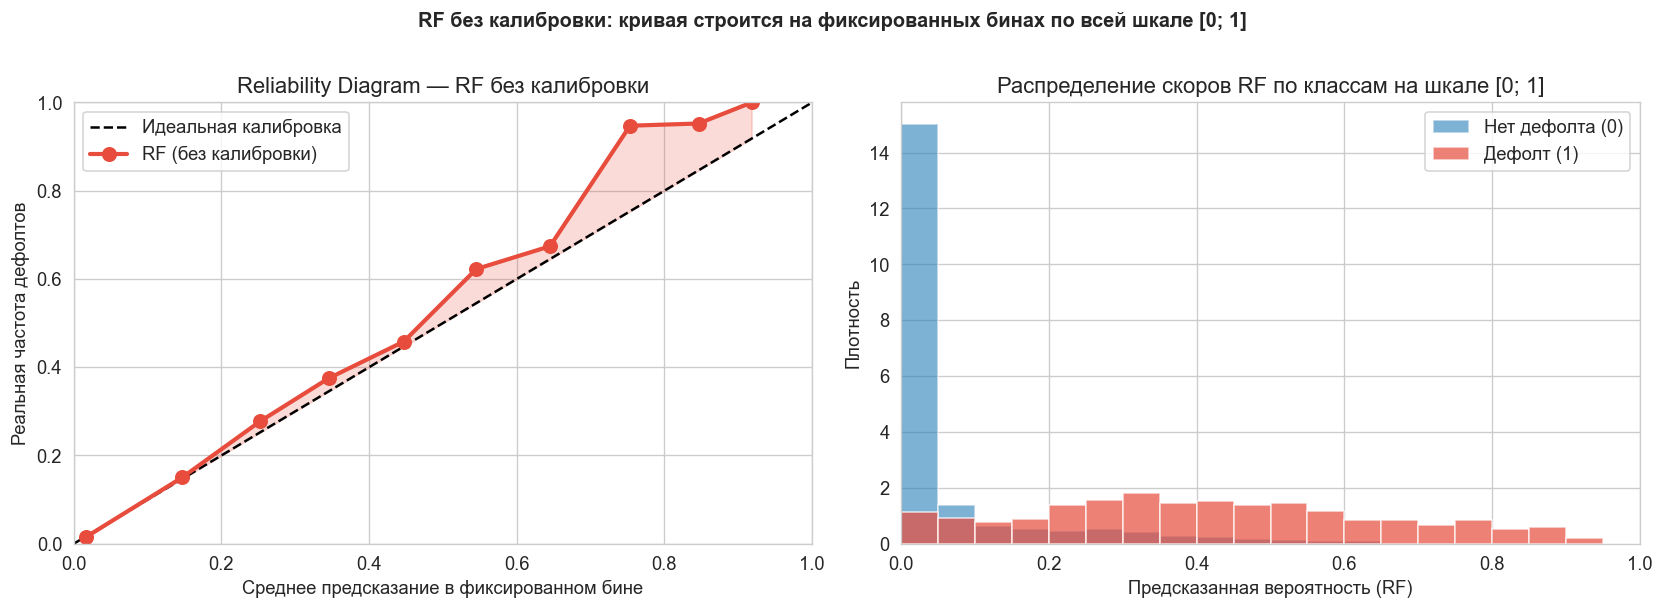

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
mean_pred, frac_pos = get_calibration_curve(y_test.values, scores_test, n_bins=10, strategy="uniform")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка")
ax.plot(mean_pred, frac_pos, "o-", color=COLORS[0], lw=2.5, ms=8, label="RF (без калибровки)")
ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.2, color=COLORS[0])
ax.set_xlabel("Среднее предсказание в фиксированном бине")
ax.set_ylabel("Реальная частота дефолтов")
ax.set_title("Reliability Diagram — RF без калибровки")
ax.legend()

x_max = max(scores_test.max() * 1.1, 0.35)
y_max = max(frac_pos.max() * 1.15, 0.35)
ax.set_xlim(0, min(x_max, 1.0))
ax.set_ylim(0, min(y_max, 1.0))

ax = axes[1]
ax.hist(scores_test[y_test == 0], bins=np.linspace(0, 1, 21), alpha=0.6, label="Нет дефолта (0)", color=COLORS[1], density=True)
ax.hist(scores_test[y_test == 1], bins=np.linspace(0, 1, 21), alpha=0.7, label="Дефолт (1)", color=COLORS[0], density=True)
ax.set_xlim(0, 1)
ax.set_xlabel("Предсказанная вероятность (RF)")
ax.set_ylabel("Плотность")
ax.set_title("Распределение скоров RF по классам на шкале [0; 1]")
ax.legend()

plt.suptitle(
    "RF без калибровки: кривая строится на фиксированных бинах по всей шкале [0; 1]",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


### Почему RF без калибровки может быть неидеальной

Хорошее ранжирование не означает хорошую вероятность дефолта. Random Forest может хорошо отделять дефолтных заемщиков от недефолтных, но его сырые `predict_proba` часто требуют посткалибровки:

- **AUC/Gini/KS** отвечают за порядок заемщиков по риску.
- **Brier, Log-Loss, ECE, calibration slope/intercept** отвечают за качество численных PD.
- Если `slope` заметно отличается от 1, модель неверно масштабирует риск.
- Если `intercept` заметно отличается от 0, модель систематически завышает или занижает уровень PD.

Большой пик недефолтных клиентов в низких PD — это нормально: в кредитном портфеле большинство заемщиков не дефолтит, а хорошая модель должна концентрировать таких клиентов в левой части шкалы.

## 5. Сравнение методов калибровки

В итоговом сравнении оставлена **одна базовая сплайн-модель** — **сплайн-калибровка с монотонным ограничением**.  
Причина: для PD-калибровки монотонность является содержательно предпочтительной, поскольку более высокий исходный риск не должен переводиться в более низкую итоговую PD.

Дополнительно вводится **французский сплайн-калибровка** — двухшаговый метод, в котором:
1. исходные PD сначала калибруются **логит-моделью**;
2. затем полученные логит-калиброванные PD дополнительно сглаживаются **монотонным сплайном**.

Таким образом, в ноутбуке сопоставляются простые параметрические, непараметрические и гибридные методы калибровки PD.

In [8]:
calibrators = get_all_calibrators()
calibrated_probs = {}

for name, cal in calibrators.items():
    cal.fit(scores_calib, y_calib.values)
    calibrated_probs[name] = np.clip(cal.predict(scores_test), 1e-6, 1 - 1e-6)
    print(f"{name}: обучен.")

print("\nВсе калибраторы обучены только на calibration-выборке.")

Logit calibration: обучен.
Isotonic regression: обучен.
Beta calibration: обучен.
Monotone spline: обучен.
French spline: обучен.

Все калибраторы обучены только на calibration-выборке.


### Единый исходный score для всех методов

Все методы калибровки получают на вход один и тот же неоткалиброванный RF-score. Дальше различается только функция преобразования `raw_score -> calibrated PD`. Поэтому сравнение методов корректно: объект, его исходный score, EAD и факт дефолта остаются одинаковыми, меняется только откалиброванная PD и рейтинг, назначенный по этой PD.

In [9]:
calibration_method_names = ["RF без калибровки", *list(calibrators.keys())]

raw_score_input_check = pd.DataFrame({
    "method": calibration_method_names,
    "n_obs": len(scores_test),
    "raw_score_min": float(scores_test.min()),
    "raw_score_mean": float(scores_test.mean()),
    "raw_score_max": float(scores_test.max()),
    "raw_score_p50": float(np.quantile(scores_test, 0.50)),
    "raw_score_p95": float(np.quantile(scores_test, 0.95)),
})

score_columns = ["raw_score_min", "raw_score_mean", "raw_score_max", "raw_score_p50", "raw_score_p95"]
raw_score_sync_diff = raw_score_input_check[score_columns].max() - raw_score_input_check[score_columns].min()
if float(raw_score_sync_diff.max()) > 1e-12:
    raise ValueError("Raw RF score differs across calibration methods.")

print("Проверка единого исходного score: все методы используют один и тот же RF-score.")
display(
    raw_score_input_check
    .style.format({
        "raw_score_min": "{:.4f}",
        "raw_score_mean": "{:.4f}",
        "raw_score_max": "{:.4f}",
        "raw_score_p50": "{:.4f}",
        "raw_score_p95": "{:.4f}",
    })
)

master_score_bins = np.r_[
    master_scale_table()["pd_lower"].to_numpy(),
    master_scale_table()["pd_upper"].iloc[-1],
]
score_distribution_2024 = score_distribution_table(
    scores_test,
    y_test.values,
    bins=master_score_bins,
)

print("Распределение исходного RF-score за 2024 год по границам мастер-шкалы:")
display(
    score_distribution_2024[score_distribution_2024["n_assets"] > 0]
    .style.format({
        "score_min": "{:.4f}",
        "score_max": "{:.4f}",
        "avg_score": "{:.4f}",
        "observed_default_rate": "{:.2%}",
        "portfolio_count_share": "{:.1%}",
    })
)


Проверка единого исходного score: все методы используют один и тот же RF-score.


,method,n_obs,raw_score_min,raw_score_mean,raw_score_max,raw_score_p50,raw_score_p95
0,RF без калибровки,6372,0.0003,0.1046,0.9383,0.0212,0.5154
1,Logit calibration,6372,0.0003,0.1046,0.9383,0.0212,0.5154
2,Isotonic regression,6372,0.0003,0.1046,0.9383,0.0212,0.5154
3,Beta calibration,6372,0.0003,0.1046,0.9383,0.0212,0.5154
4,Monotone spline,6372,0.0003,0.1046,0.9383,0.0212,0.5154
5,French spline,6372,0.0003,0.1046,0.9383,0.0212,0.5154


Распределение исходного RF-score за 2024 год по границам мастер-шкалы:


,score_bin,n_assets,score_min,score_max,avg_score,defaults,observed_default_rate,portfolio_count_share
0,"(-0.001, 0.01]",2479,0.0003,0.0100,0.0015,0.000000,0.00%,38.9%
1,"(0.01, 0.015]",213,0.0100,0.0150,0.0127,2.000000,0.94%,3.3%
2,"(0.015, 0.0195]",347,0.0150,0.0195,0.0175,5.000000,1.44%,5.4%
3,"(0.0195, 0.03]",715,0.0195,0.0300,0.0241,16.000000,2.24%,11.2%
4,"(0.03, 0.043]",417,0.0300,0.0429,0.0356,12.000000,2.88%,6.5%
5,"(0.043, 0.049]",110,0.0432,0.0489,0.0458,5.000000,4.55%,1.7%
6,"(0.049, 0.06]",157,0.0491,0.0599,0.0541,12.000000,7.64%,2.5%
7,"(0.06, 0.09]",218,0.0600,0.0895,0.0729,15.000000,6.88%,3.4%
8,"(0.09, 0.14]",241,0.0904,0.1399,0.1132,31.000000,12.86%,3.8%
9,"(0.14, 0.22]",272,0.1400,0.2198,0.1792,50.000000,18.38%,4.3%


### Мастер-шкала PD: распределение 2024 по рабочим границам

Мастер-шкала `A1 ... E` здесь используется как рабочая портфельная шкала для полного stress-потока 2024 с CT около 10-12%. Границы не копируют справочную картинку один в один: они расширены и сдвинуты так, чтобы все методы калибровки попадали в каждую категорию, а минимальная ширина бакета была не меньше 0.05 п.п. Рейтинг по-прежнему назначается по откалиброванной PD, а не равными группами score.

In [10]:
TARGET_CT = float(y_calib.mean())
ASSET_EAD = 1_000_000.0

df_test_master = df.loc[y_test.index].copy()

rating_scale_predictions = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

master_scale_panel = method_master_scale_distribution(
    df_test_master,
    rating_scale_predictions,
    default_asset_ead=ASSET_EAD,
).copy()

score_by_rating_rows = []
for method, pd_values in rating_scale_predictions.items():
    rating_by_pd = assign_pd_master_scale_ratings(pd_values)
    score_work = pd.DataFrame({"rating": rating_by_pd, "score": scores_test})
    score_by_rating = (
        score_work.groupby("rating", observed=False)["score"]
        .mean()
        .reindex(MASTER_SCALE_RATINGS)
        .reset_index(name="avg_score")
    )
    score_by_rating["method"] = method
    score_by_rating_rows.append(score_by_rating)

master_scale_panel = master_scale_panel.merge(
    pd.concat(score_by_rating_rows, ignore_index=True),
    on=["method", "rating"],
    how="left",
)

# Для RWA используем среднее значение PD из заданной мастер-шкалы.
# Фактическая средняя PD внутри бакета остается в колонке avg_pd.
master_scale_panel["pd_rating"] = master_scale_panel["pd_avg_master"]
master_scale_panel["pd_before_target"] = master_scale_panel["avg_pd"]
master_scale_panel["one_minus_pd"] = 1.0 - master_scale_panel["pd_rating"]
master_scale_panel["expected_defaults"] = master_scale_panel["pd_rating"] * master_scale_panel["n_assets"]
master_scale_panel["expected_default_ead"] = master_scale_panel["pd_rating"] * master_scale_panel["total_ead"]
master_scale_panel["default_gap"] = master_scale_panel["defaults"] - master_scale_panel["expected_defaults"]
master_scale_panel["calibration_ratio"] = np.where(
    master_scale_panel["expected_defaults"] > 0.0,
    master_scale_panel["defaults"] / master_scale_panel["expected_defaults"],
    np.nan,
)

summary_rows = []
for method, frame in master_scale_panel.groupby("method", sort=False):
    active = frame[frame["n_assets"] > 0].copy()
    total_ead = active["total_ead"].sum()
    summary_rows.append({
        "method": method,
        "n_assets": int(active["n_assets"].sum()),
        "total_ead": float(total_ead),
        "defaults": float(active["defaults"].sum()),
        "target_weighted_pd": float(np.average(active["pd_rating"], weights=active["total_ead"])),
        "avg_individual_pd": float(np.average(active["avg_pd"], weights=active["n_assets"])),
        "expected_defaults": float(active["expected_defaults"].sum()),
        "pd_min": float(active["pd_min"].min()),
        "pd_max": float(active["pd_max"].max()),
    })
master_scale_summary = pd.DataFrame(summary_rows).set_index("method")

master_scale_assumptions = IRBAssumptions(lgd=0.40, maturity_years=2.5, ead=ASSET_EAD)

master_scale_capital = rating_scale_capital(
    master_scale_panel,
    assumptions=master_scale_assumptions,
    method_col="method",
)

master_scale_rwa_by_rating = rating_scale_capital_by_rating(
    master_scale_panel,
    assumptions=master_scale_assumptions,
    method_col="method",
    rating_col="rating",
    pd_col="pd_rating",
    rating_order=MASTER_SCALE_RATINGS,
)

# Empty buckets stay in the table with zero EAD/RWA, so every method is displayed
# on the same A1...E axis even when its first populated rating is lower than A1.
rwa_sync_check = (
    master_scale_rwa_by_rating
    .groupby("method", observed=False)[["total_expected_loss", "total_rwa", "total_required_capital"]]
    .sum()
    .join(
        master_scale_capital[["total_expected_loss", "total_rwa", "total_required_capital"]],
        lsuffix="_by_rating",
        rsuffix="_summary",
    )
)
for metric in ["total_expected_loss", "total_rwa", "total_required_capital"]:
    rwa_sync_check[f"{metric}_diff"] = (
        rwa_sync_check[f"{metric}_by_rating"] - rwa_sync_check[f"{metric}_summary"]
    ).abs()

max_rwa_sync_diff = float(
    rwa_sync_check[[col for col in rwa_sync_check.columns if col.endswith("_diff")]].max().max()
)
if max_rwa_sync_diff > 1e-4:
    raise ValueError("RWA tables are not synchronized with the master-scale summary.")

pd_bound_capital = master_scale_pd_bound_capital(
    master_scale_panel,
    assumptions=master_scale_assumptions,
)

master_scale_bounds = (
    master_scale_panel[["rating", "pd_lower", "pd_avg_master", "pd_upper"]]
    .drop_duplicates(subset=["rating"])
    .set_index("rating")
    .reindex(MASTER_SCALE_RATINGS)
)

rating_pd_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="avg_pd")
    .reindex(MASTER_SCALE_RATINGS)
)

rating_pd_matrix_display = rating_pd_matrix.map(
    lambda x: "" if pd.isna(x) else f"{x:.2%}"
)

print(f"Target CT по calibration-периоду: {TARGET_CT:.2%}")
print(f"OOT default rate:                 {y_test.mean():.2%}")
print(f"EAD на один актив:                {ASSET_EAD:,.0f}")
print("Границы фиксированной мастер-шкалы PD:")
display(
    master_scale_bounds.style.format({
        "pd_lower": "{:.2%}",
        "pd_avg_master": "{:.2%}",
        "pd_upper": "{:.2%}",
    })
)

print("Средняя индивидуальная PD внутри рейтинга по методам калибровки:")
display(rating_pd_matrix_display)



rating_coverage_matrix = (
    master_scale_panel
    .assign(has_assets=lambda x: x["n_assets"].gt(0))
    .pivot(index="rating", columns="method", values="has_assets")
    .reindex(MASTER_SCALE_RATINGS)
    .fillna(False)
)

rating_count_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="n_assets")
    .reindex(MASTER_SCALE_RATINGS)
    .fillna(0)
    .astype(int)
)

print("\u041f\u043e\u043a\u0440\u044b\u0442\u0438\u0435 \u043a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u0439 A1-E \u043f\u043e \u043c\u0435\u0442\u043e\u0434\u0430\u043c: \u0447\u0438\u0441\u043b\u043e \u0430\u043a\u0442\u0438\u0432\u043e\u0432 \u0432 \u043a\u0430\u0436\u0434\u043e\u043c \u0440\u0435\u0439\u0442\u0438\u043d\u0433\u0435")
display(rating_count_matrix)
print("\u0415\u0441\u043b\u0438 \u0432 \u044f\u0447\u0435\u0439\u043a\u0435 0, \u044d\u0442\u043e \u043d\u0435 \u043e\u0448\u0438\u0431\u043a\u0430 \u0442\u0430\u0431\u043b\u0438\u0446\u044b: \u0434\u0430\u043d\u043d\u0430\u044f \u043a\u0430\u043b\u0438\u0431\u0440\u043e\u0432\u043a\u0430 \u043d\u0435 \u043f\u043e\u043c\u0435\u0441\u0442\u0438\u043b\u0430 \u043d\u0438 \u043e\u0434\u043d\u043e\u0433\u043e \u0437\u0430\u0435\u043c\u0449\u0438\u043a\u0430 \u0432 \u044d\u0442\u043e\u0442 PD-\u0434\u0438\u0430\u043f\u0430\u0437\u043e\u043d \u043c\u0430\u0441\u0442\u0435\u0440-\u0448\u043a\u0430\u043b\u044b.")

print("Итог по методам: средняя PD мастер-шкалы, средняя индивидуальная PD и диапазон PD:")
display(
    master_scale_summary[[
        "n_assets",
        "target_weighted_pd",
        "avg_individual_pd",
        "defaults",
        "expected_defaults",
        "pd_min",
        "pd_max",
    ]]
    .style.format({
        "target_weighted_pd": "{:.2%}",
        "avg_individual_pd": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "pd_min": "{:.2%}",
        "pd_max": "{:.2%}",
    })
)

master_scale_view_cols = [
    "method",
    "rating",
    "avg_score",
    "n_assets",
    "portfolio_count_share",
    "observed_default_rate",
    "pd_min",
    "avg_pd",
    "pd_max",
    "pd_lower",
    "pd_rating",
    "pd_upper",
    "expected_defaults",
]
print("Распределение портфеля по фиксированной мастер-шкале для всех методов:")
display(
    master_scale_panel.loc[:, master_scale_view_cols]
    .style.format({
        "avg_score": "{:.4f}",
        "portfolio_count_share": "{:.1%}",
        "observed_default_rate": "{:.2%}",
        "pd_min": "{:.2%}",
        "avg_pd": "{:.2%}",
        "pd_max": "{:.2%}",
        "pd_lower": "{:.2%}",
        "pd_rating": "{:.2%}",
        "pd_upper": "{:.2%}",
        "expected_defaults": "{:.2f}",
    }, na_rep="")
)


Target CT по calibration-периоду: 9.32%
OOT default rate:                 11.19%
EAD на один актив:                1,000,000
Границы фиксированной мастер-шкалы PD:


,pd_lower,pd_avg_master,pd_upper
rating,,,
A1,0.00%,0.50%,1.00%
A2,1.00%,1.25%,1.50%
A3,1.50%,1.73%,1.95%
B1,1.95%,2.48%,3.00%
B2,3.00%,3.65%,4.30%
B3,4.30%,4.60%,4.90%
C1,4.90%,5.45%,6.00%
C2,6.00%,7.50%,9.00%
C3,9.00%,11.50%,14.00%


Средняя индивидуальная PD внутри рейтинга по методам калибровки:


method,Beta calibration,French spline,Isotonic regression,Logit calibration,Monotone spline,RF без калибровки
rating,,,,,,
A1,0.14%,0.23%,0.08%,0.14%,0.41%,0.15%
A2,1.28%,1.26%,1.38%,1.27%,1.25%,1.27%
A3,1.71%,1.77%,,1.71%,1.70%,1.75%
B1,2.41%,2.35%,2.22%,2.41%,2.51%,2.41%
B2,3.58%,3.64%,,3.58%,3.55%,3.56%
B3,4.57%,4.64%,4.64%,4.57%,4.67%,4.58%
C1,5.41%,5.33%,,5.40%,5.41%,5.41%
C2,7.40%,7.28%,7.49%,7.41%,7.28%,7.29%
C3,11.26%,11.54%,10.49%,11.29%,11.65%,11.32%


Покрытие категорий A1-E по методам: число активов в каждом рейтинге


method,Beta calibration,French spline,Isotonic regression,Logit calibration,Monotone spline,RF без калибровки
rating,,,,,,
A1,2648,2643,2727,2671,2637,2479
A2,491,189,224,505,129,213
A3,427,233,0,417,110,347
B1,518,1096,1276,498,1295,715
B2,285,144,0,282,99,417
B3,87,203,490,84,314,110
C1,110,116,0,109,90,157
C2,185,162,71,184,118,218
C3,218,143,70,216,117,241


Если в ячейке 0, это не ошибка таблицы: данная калибровка не поместила ни одного заемщика в этот PD-диапазон мастер-шкалы.
Итог по методам: средняя PD мастер-шкалы, средняя индивидуальная PD и диапазон PD:


,n_assets,target_weighted_pd,avg_individual_pd,defaults,expected_defaults,pd_min,pd_max
method,,,,,,,
RF без калибровки,6372,10.73%,10.46%,713.000000,683.76,0.03%,93.83%
Logit calibration,6372,10.12%,9.86%,713.000000,645.04,0.01%,95.01%
Isotonic regression,6372,10.15%,9.87%,713.000000,646.50,0.00%,100.00%
Beta calibration,6372,10.10%,9.86%,713.000000,643.43,0.01%,95.56%
Monotone spline,6372,9.94%,9.58%,713.000000,633.42,0.35%,71.16%
French spline,6372,10.03%,9.59%,713.000000,639.37,0.10%,71.51%


Распределение портфеля по фиксированной мастер-шкале для всех методов:


,method,rating,avg_score,n_assets,portfolio_count_share,observed_default_rate,pd_min,avg_pd,pd_max,pd_lower,pd_rating,pd_upper,expected_defaults
0,RF без калибровки,A1,0.0015,2479,38.9%,0.00%,0.03%,0.15%,1.00%,0.00%,0.50%,1.00%,12.39
1,RF без калибровки,A2,0.0127,213,3.3%,0.94%,1.00%,1.27%,1.50%,1.00%,1.25%,1.50%,2.66
2,RF без калибровки,A3,0.0175,347,5.4%,1.44%,1.50%,1.75%,1.95%,1.50%,1.73%,1.95%,6.00
3,RF без калибровки,B1,0.0241,715,11.2%,2.24%,1.95%,2.41%,3.00%,1.95%,2.48%,3.00%,17.73
4,RF без калибровки,B2,0.0356,417,6.5%,2.88%,3.00%,3.56%,4.29%,3.00%,3.65%,4.30%,15.22
5,RF без калибровки,B3,0.0458,110,1.7%,4.55%,4.32%,4.58%,4.89%,4.30%,4.60%,4.90%,5.06
6,RF без калибровки,C1,0.0541,157,2.5%,7.64%,4.91%,5.41%,5.99%,4.90%,5.45%,6.00%,8.56
7,RF без калибровки,C2,0.0729,218,3.4%,6.88%,6.00%,7.29%,8.95%,6.00%,7.50%,9.00%,16.35
8,RF без калибровки,C3,0.1132,241,3.8%,12.86%,9.04%,11.32%,13.99%,9.00%,11.50%,14.00%,27.71
9,RF без калибровки,D1,0.1792,272,4.3%,18.38%,14.00%,17.92%,21.98%,14.00%,18.00%,22.00%,48.96


1. Все методы используют один и тот же исходный RF-score; это проверяется отдельной таблицей выше.
2. Рейтинг назначается по откалиброванной PD, поэтому разные методы могут по-разному распределять одних и тех же заемщиков по рейтингам.
3. Пустой рейтинг означает `0` активов в этом бакете для конкретного метода. В матрицах такие места показываются пустыми ячейками.
4. `Expected loss + unexpected loss = capital` отражено в расчете 845-П: резервы интерпретируются как expected loss, а `RWA_capital` - как unexpected loss.

### Диагностика покрытия мастер-шкалы

Перед RWA-графиками фиксируем два разных факта: полная техническая ось таблиц всегда `A1...E`, а фактический портфель конкретного метода может начинаться ниже `A1`, если в верхние PD-бакеты не попал ни один заемщик. Это ожидаемое следствие назначения рейтинга по откалиброванной PD, а не ошибка мастер-шкалы.

In [11]:
first_populated_rows = []
for method in rating_count_matrix.columns:
    counts = rating_count_matrix[method]
    populated = counts[counts > 0]
    first_rating = populated.index[0] if len(populated) else None
    last_rating = populated.index[-1] if len(populated) else None
    leading_empty = list(counts.index[: counts.index.get_loc(first_rating)]) if first_rating is not None else list(counts.index)
    first_populated_rows.append({
        "method": method,
        "technical_axis_start": MASTER_SCALE_RATINGS[0],
        "first_populated_rating": first_rating,
        "last_populated_rating": last_rating,
        "leading_empty_ratings": ", ".join(leading_empty) if leading_empty else "нет",
        "empty_ratings_before_first": len(leading_empty),
        "populated_ratings": int((counts > 0).sum()),
        "total_assets": int(counts.sum()),
    })

first_populated_diagnostic = pd.DataFrame(first_populated_rows).set_index("method")

rwa_axis_check = (
    master_scale_rwa_by_rating
    .assign(rating=lambda x: x["rating"].astype(str))
    .groupby("method", sort=False)["rating"]
    .agg(
        rwa_table_axis_start="first",
        rwa_table_axis_end="last",
        rwa_table_rows="size",
        keeps_full_master_axis=lambda s: list(s) == list(MASTER_SCALE_RATINGS),
    )
)

print("Где фактически начинается портфель каждого метода внутри фиксированной мастер-шкалы:")
display(first_populated_diagnostic)

print("Контроль технической оси RWA-таблицы: каждый метод должен сохранять A1...E, даже при пустых начальных бакетах:")
display(rwa_axis_check)

if not rwa_axis_check["keeps_full_master_axis"].all():
    raise ValueError("RWA table lost the common A1...E master-scale axis for at least one method.")


Где фактически начинается портфель каждого метода внутри фиксированной мастер-шкалы:


,technical_axis_start,first_populated_rating,last_populated_rating,leading_empty_ratings,empty_ratings_before_first,populated_ratings,total_assets
method,,,,,,,
Beta calibration,A1,A1,E,нет,0,13,6372
French spline,A1,A1,E,нет,0,13,6372
Isotonic regression,A1,A1,E,нет,0,10,6372
Logit calibration,A1,A1,E,нет,0,13,6372
Monotone spline,A1,A1,E,нет,0,13,6372
RF без калибровки,A1,A1,E,нет,0,13,6372


Контроль технической оси RWA-таблицы: каждый метод должен сохранять A1...E, даже при пустых начальных бакетах:


,rwa_table_axis_start,rwa_table_axis_end,rwa_table_rows,keeps_full_master_axis
method,,,,
RF без калибровки,A1,E,13,True
Logit calibration,A1,E,13,True
Isotonic regression,A1,E,13,True
Beta calibration,A1,E,13,True
Monotone spline,A1,E,13,True
French spline,A1,E,13,True


### Контроль синхронизации таблиц и графиков

После перехода на фиксированные PD-границы мастер-шкалы распределение заемщиков по рейтингам может отличаться между методами калибровки. Это ожидаемо: метод меняет откалиброванную PD, а рейтинг назначается уже по этой PD.

Чтобы таблицы и графики не расходились, RWA по категориям строится из единой таблицы `master_scale_rwa_by_rating`. Суммы по рейтингам сверяются с итоговой таблицей `master_scale_capital`; если появляется расхождение, ноутбук останавливается с ошибкой.

Диагностическая матрица: доля портфеля по категориям мастер-шкалы для всех методов:


method,Beta calibration,French spline,Isotonic regression,Logit calibration,Monotone spline,RF без калибровки
rating,,,,,,
A1,41.6%,41.5%,42.8%,41.9%,41.4%,38.9%
A2,7.7%,3.0%,3.5%,7.9%,2.0%,3.3%
A3,6.7%,3.7%,0.0%,6.5%,1.7%,5.4%
B1,8.1%,17.2%,20.0%,7.8%,20.3%,11.2%
B2,4.5%,2.3%,0.0%,4.4%,1.6%,6.5%
B3,1.4%,3.2%,7.7%,1.3%,4.9%,1.7%
C1,1.7%,1.8%,0.0%,1.7%,1.4%,2.5%
C2,2.9%,2.5%,1.1%,2.9%,1.9%,3.4%
C3,3.4%,2.2%,1.1%,3.4%,1.8%,3.8%


Диагностическая матрица: доля RWA по категориям мастер-шкалы для всех методов:


method,Beta calibration,French spline,Isotonic regression,Logit calibration,Monotone spline,RF без калибровки
rating,,,,,,
A1,23.1%,22.7%,23.5%,23.3%,22.5%,20.8%
A2,6.1%,2.3%,2.8%,6.3%,1.6%,2.6%
A3,5.9%,3.2%,0.0%,5.8%,1.5%,4.6%
B1,7.9%,16.5%,19.3%,7.6%,19.3%,10.5%
B2,4.8%,2.4%,0.0%,4.8%,1.6%,6.8%
B3,1.6%,3.6%,8.9%,1.5%,5.6%,1.9%
C1,2.1%,2.2%,0.0%,2.1%,1.7%,2.9%
C2,4.0%,3.5%,1.5%,4.0%,2.5%,4.5%
C3,5.5%,3.6%,1.8%,5.5%,2.9%,5.9%


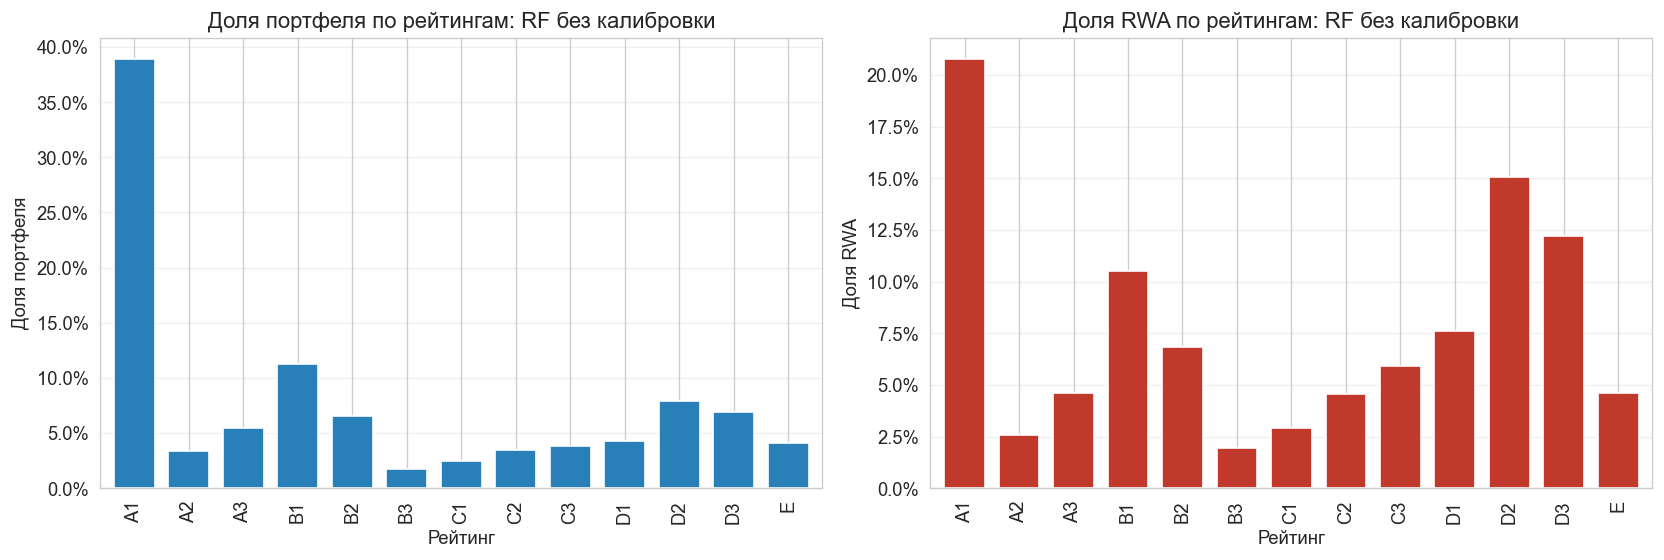

Главный график построен по одному методу, потому что разные калибровки по-разному переводят один и тот же score в PD. Сравнение всех методов оставлено выше как диагностическая матрица.
RWA по категориям для того же метода, что использован на графике:


,method,rating,n_assets,portfolio_count_share,pd_min,avg_pd,pd_max,pd_rating,total_expected_loss,total_rwa,rwa_share,total_required_capital
0,RF без калибровки,A1,2479,38.9%,0.03%,0.15%,1.00%,0.50%,"4,958,000","122,714,663",20.8%,"127,672,663"
1,RF без калибровки,A2,213,3.3%,1.00%,1.27%,1.50%,1.25%,"1,065,000","15,096,010",2.6%,"16,161,010"
2,RF без калибровки,A3,347,5.4%,1.50%,1.75%,1.95%,1.73%,"2,401,240","27,189,733",4.6%,"29,590,973"
3,RF без калибровки,B1,715,11.2%,1.95%,2.41%,3.00%,2.48%,"7,092,800","61,972,874",10.5%,"69,065,674"
4,RF без калибровки,B2,417,6.5%,3.00%,3.56%,4.29%,3.65%,"6,088,200","40,274,093",6.8%,"46,362,293"
5,RF без калибровки,B3,110,1.7%,4.32%,4.58%,4.89%,4.60%,"2,024,000","11,405,807",1.9%,"13,429,807"
6,RF без калибровки,C1,157,2.5%,4.91%,5.41%,5.99%,5.45%,"3,422,600","17,227,405",2.9%,"20,650,005"
7,RF без калибровки,C2,218,3.4%,6.00%,7.29%,8.95%,7.50%,"6,540,000","26,862,864",4.5%,"33,402,864"
8,RF без калибровки,C3,241,3.8%,9.04%,11.32%,13.99%,11.50%,"11,086,000","34,807,340",5.9%,"45,893,340"
9,RF без калибровки,D1,272,4.3%,14.00%,17.92%,21.98%,18.00%,"19,584,000","45,011,586",7.6%,"64,595,586"


Проверка синхронизации таблицы RWA: максимальное расхождение = 0.000000
Чувствительность капитала к нижней, средней и верхней PD мастер-шкалы:


,method,pd_scenario,total_ead,avg_pd_weighted,total_reserves,total_expected_loss,total_rwa_capital,total_unexpected_loss_capital,total_capital_true,total_rwa,total_required_capital,capital_true_rate_to_ead,delta_capital_true_vs_avg,delta_capital_true_vs_avg_pct
0,Beta calibration,pd_lower,"6,372,000,000",7.75%,197912560.000000,"197,912,560",460272947.043387,460272947.043387,658185507.043387,"460,272,947","658,185,507",10.33%,"-167,200,009",-20.26%
1,Beta calibration,pd_avg_master,"6,372,000,000",10.10%,257370200.000000,"257,370,200",568015316.443300,568015316.443300,825385516.443300,"568,015,316","825,385,516",12.95%,0,0.00%
2,Beta calibration,pd_upper,"6,372,000,000",13.06%,332767695.600000,"332,767,696",588205002.743618,588205002.743618,920972698.343618,"588,205,003","920,972,698",14.45%,"95,587,182",11.58%
3,French spline,pd_lower,"6,372,000,000",7.70%,196625160.000000,"196,625,160",468462716.969533,468462716.969533,665087876.969533,"468,462,717","665,087,877",10.44%,"-167,716,273",-20.14%
4,French spline,pd_avg_master,"6,372,000,000",10.03%,255746080.000000,"255,746,080",577058070.307538,577058070.307538,832804150.307538,"577,058,070","832,804,150",13.07%,0,0.00%
5,French spline,pd_upper,"6,372,000,000",12.85%,327490917.600000,"327,490,918",601279232.993460,601279232.993460,928770150.593460,"601,279,233","928,770,151",14.58%,"95,966,000",11.52%
6,Isotonic regression,pd_lower,"6,372,000,000",7.79%,198984040.000000,"198,984,040",463284324.413566,463284324.413566,662268364.413566,"463,284,324","662,268,364",10.39%,"-169,711,975",-20.40%
7,Isotonic regression,pd_avg_master,"6,372,000,000",10.15%,258601920.000000,"258,601,920",573378418.994799,573378418.994799,831980338.994799,"573,378,419","831,980,339",13.06%,0,0.00%
8,Isotonic regression,pd_upper,"6,372,000,000",13.01%,331515913.200000,"331,515,913",596415797.341571,596415797.341571,927931710.541571,"596,415,797","927,931,711",14.56%,"95,951,372",11.53%
9,Logit calibration,pd_lower,"6,372,000,000",7.77%,198356120.000000,"198,356,120",458705579.681641,458705579.681641,657061699.681641,"458,705,580","657,061,700",10.31%,"-168,048,432",-20.37%


In [12]:
rwa_share_matrix = (
    master_scale_rwa_by_rating
    .pivot(index="rating", columns="method", values="rwa_share")
    .reindex(MASTER_SCALE_RATINGS)
    .fillna(0.0)
)

portfolio_share_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="portfolio_count_share")
    .reindex(MASTER_SCALE_RATINGS)
    .fillna(0.0)
)

MAIN_RATING_METHOD = "RF \u0431\u0435\u0437 \u043a\u0430\u043b\u0438\u0431\u0440\u043e\u0432\u043a\u0438"
if MAIN_RATING_METHOD not in portfolio_share_matrix.columns:
    MAIN_RATING_METHOD = portfolio_share_matrix.columns[0]

print("\u0414\u0438\u0430\u0433\u043d\u043e\u0441\u0442\u0438\u0447\u0435\u0441\u043a\u0430\u044f \u043c\u0430\u0442\u0440\u0438\u0446\u0430: \u0434\u043e\u043b\u044f \u043f\u043e\u0440\u0442\u0444\u0435\u043b\u044f \u043f\u043e \u043a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u044f\u043c \u043c\u0430\u0441\u0442\u0435\u0440-\u0448\u043a\u0430\u043b\u044b \u0434\u043b\u044f \u0432\u0441\u0435\u0445 \u043c\u0435\u0442\u043e\u0434\u043e\u0432:")
display(
    portfolio_share_matrix
    .style.format("{:.1%}")
    .background_gradient(axis=None, cmap="Blues")
)

print("\u0414\u0438\u0430\u0433\u043d\u043e\u0441\u0442\u0438\u0447\u0435\u0441\u043a\u0430\u044f \u043c\u0430\u0442\u0440\u0438\u0446\u0430: \u0434\u043e\u043b\u044f RWA \u043f\u043e \u043a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u044f\u043c \u043c\u0430\u0441\u0442\u0435\u0440-\u0448\u043a\u0430\u043b\u044b \u0434\u043b\u044f \u0432\u0441\u0435\u0445 \u043c\u0435\u0442\u043e\u0434\u043e\u0432:")
display(
    rwa_share_matrix
    .style.format("{:.1%}")
    .background_gradient(axis=None, cmap="Oranges")
)

selected_distribution = pd.DataFrame({
    "portfolio_share": portfolio_share_matrix[MAIN_RATING_METHOD],
    "rwa_share": rwa_share_matrix[MAIN_RATING_METHOD],
}).reindex(MASTER_SCALE_RATINGS).fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=False)

selected_distribution["portfolio_share"].plot(
    kind="bar",
    ax=axes[0],
    color="#2980b9",
    width=0.75,
)
axes[0].set_title(f"\u0414\u043e\u043b\u044f \u043f\u043e\u0440\u0442\u0444\u0435\u043b\u044f \u043f\u043e \u0440\u0435\u0439\u0442\u0438\u043d\u0433\u0430\u043c: {MAIN_RATING_METHOD}")
axes[0].set_xlabel("\u0420\u0435\u0439\u0442\u0438\u043d\u0433")
axes[0].set_ylabel("\u0414\u043e\u043b\u044f \u043f\u043e\u0440\u0442\u0444\u0435\u043b\u044f")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].grid(True, axis="y", alpha=0.3)

selected_distribution["rwa_share"].plot(
    kind="bar",
    ax=axes[1],
    color="#c0392b",
    width=0.75,
)
axes[1].set_title(f"\u0414\u043e\u043b\u044f RWA \u043f\u043e \u0440\u0435\u0439\u0442\u0438\u043d\u0433\u0430\u043c: {MAIN_RATING_METHOD}")
axes[1].set_xlabel("\u0420\u0435\u0439\u0442\u0438\u043d\u0433")
axes[1].set_ylabel("\u0414\u043e\u043b\u044f RWA")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(
    "\u0413\u043b\u0430\u0432\u043d\u044b\u0439 \u0433\u0440\u0430\u0444\u0438\u043a \u043f\u043e\u0441\u0442\u0440\u043e\u0435\u043d \u043f\u043e \u043e\u0434\u043d\u043e\u043c\u0443 \u043c\u0435\u0442\u043e\u0434\u0443, \u043f\u043e\u0442\u043e\u043c\u0443 \u0447\u0442\u043e \u0440\u0430\u0437\u043d\u044b\u0435 \u043a\u0430\u043b\u0438\u0431\u0440\u043e\u0432\u043a\u0438 "
    "\u043f\u043e-\u0440\u0430\u0437\u043d\u043e\u043c\u0443 \u043f\u0435\u0440\u0435\u0432\u043e\u0434\u044f\u0442 \u043e\u0434\u0438\u043d \u0438 \u0442\u043e\u0442 \u0436\u0435 score \u0432 PD. \u0421\u0440\u0430\u0432\u043d\u0435\u043d\u0438\u0435 \u0432\u0441\u0435\u0445 \u043c\u0435\u0442\u043e\u0434\u043e\u0432 "
    "\u043e\u0441\u0442\u0430\u0432\u043b\u0435\u043d\u043e \u0432\u044b\u0448\u0435 \u043a\u0430\u043a \u0434\u0438\u0430\u0433\u043d\u043e\u0441\u0442\u0438\u0447\u0435\u0441\u043a\u0430\u044f \u043c\u0430\u0442\u0440\u0438\u0446\u0430."
)

print("RWA \u043f\u043e \u043a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u044f\u043c \u0434\u043b\u044f \u0442\u043e\u0433\u043e \u0436\u0435 \u043c\u0435\u0442\u043e\u0434\u0430, \u0447\u0442\u043e \u0438\u0441\u043f\u043e\u043b\u044c\u0437\u043e\u0432\u0430\u043d \u043d\u0430 \u0433\u0440\u0430\u0444\u0438\u043a\u0435:")
display(
    master_scale_rwa_by_rating.loc[
        master_scale_rwa_by_rating["method"] == MAIN_RATING_METHOD,
        [
            "method",
            "rating",
            "n_assets",
            "portfolio_count_share",
            "pd_min",
            "avg_pd",
            "pd_max",
            "pd_rating",
            "total_expected_loss",
            "total_rwa",
            "rwa_share",
            "total_required_capital",
        ],
    ]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "pd_min": "{:.2%}",
        "avg_pd": "{:.2%}",
        "pd_max": "{:.2%}",
        "pd_rating": "{:.2%}",
        "total_expected_loss": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "rwa_share": "{:.1%}",
        "total_required_capital": "{:,.0f}",
    })
)

print(f"\u041f\u0440\u043e\u0432\u0435\u0440\u043a\u0430 \u0441\u0438\u043d\u0445\u0440\u043e\u043d\u0438\u0437\u0430\u0446\u0438\u0438 \u0442\u0430\u0431\u043b\u0438\u0446\u044b RWA: \u043c\u0430\u043a\u0441\u0438\u043c\u0430\u043b\u044c\u043d\u043e\u0435 \u0440\u0430\u0441\u0445\u043e\u0436\u0434\u0435\u043d\u0438\u0435 = {max_rwa_sync_diff:,.6f}")

print("\u0427\u0443\u0432\u0441\u0442\u0432\u0438\u0442\u0435\u043b\u044c\u043d\u043e\u0441\u0442\u044c \u043a\u0430\u043f\u0438\u0442\u0430\u043b\u0430 \u043a \u043d\u0438\u0436\u043d\u0435\u0439, \u0441\u0440\u0435\u0434\u043d\u0435\u0439 \u0438 \u0432\u0435\u0440\u0445\u043d\u0435\u0439 PD \u043c\u0430\u0441\u0442\u0435\u0440-\u0448\u043a\u0430\u043b\u044b:")
display(
    pd_bound_capital.reset_index()
    .style.format({
        "avg_pd_weighted": "{:.2%}",
        "total_ead": "{:,.0f}",
        "total_expected_loss": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "total_required_capital": "{:,.0f}",
        "capital_true_rate_to_ead": "{:.2%}",
        "delta_capital_true_vs_avg": "{:,.0f}",
        "delta_capital_true_vs_avg_pct": "{:.2%}",
    })
)


In [13]:
rating_structure_shift = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="portfolio_count_share")
    .reindex(MASTER_SCALE_RATINGS)
    .fillna(0.0)
)

rating_migration_vs_rf = rating_migration_matrix(
    rating_scale_predictions,
    baseline_method="RF без калибровки",
)
rating_migration_nonzero = rating_migration_vs_rf[
    (rating_migration_vs_rf["method"] != "RF без калибровки")
    & (rating_migration_vs_rf["n_assets"] > 0)
    & (rating_migration_vs_rf["baseline_rating"] != rating_migration_vs_rf["method_rating"])
].copy()

print("Доли портфеля по рейтингам для каждого метода:")
display(
    rating_structure_shift
    .style.format("{:.1%}")
    .background_gradient(axis=None, cmap="Blues")
)

print("Фактические миграции рейтингов относительно RF без калибровки:")
display(rating_migration_nonzero)


Доли портфеля по рейтингам для каждого метода:


method,Beta calibration,French spline,Isotonic regression,Logit calibration,Monotone spline,RF без калибровки
rating,,,,,,
A1,41.6%,41.5%,42.8%,41.9%,41.4%,38.9%
A2,7.7%,3.0%,3.5%,7.9%,2.0%,3.3%
A3,6.7%,3.7%,0.0%,6.5%,1.7%,5.4%
B1,8.1%,17.2%,20.0%,7.8%,20.3%,11.2%
B2,4.5%,2.3%,0.0%,4.4%,1.6%,6.5%
B3,1.4%,3.2%,7.7%,1.3%,4.9%,1.7%
C1,1.7%,1.8%,0.0%,1.7%,1.4%,2.5%
C2,2.9%,2.5%,1.1%,2.9%,1.9%,3.4%
C3,3.4%,2.2%,1.1%,3.4%,1.8%,3.8%


Фактические миграции рейтингов относительно RF без калибровки:


,method,baseline_rating,method_rating,n_assets
182,Logit calibration,A2,A1,192
196,Logit calibration,A3,A2,347
209,Logit calibration,B1,A2,137
210,Logit calibration,B1,A3,417
224,Logit calibration,B2,B1,337
...,...,...,...,...
956,French spline,C3,C2,130
970,French spline,D1,C3,32
984,French spline,D2,D1,37
998,French spline,D3,D2,37


### Сравнение рейтинговых PD по всем методам

Теперь смотрим не один выбранный метод, а всю матрицу `rating × method`. Это показывает, как разные калибровки распределяют заемщиков по фиксированным PD-границам мастер-шкалы. Распределение по рейтингам может отличаться между методами, потому что рейтинг назначается по откалиброванной PD, а не по равным группам score.


Средняя индивидуальная PD внутри рейтинга по всем методам:


method,Beta calibration,French spline,Isotonic regression,Logit calibration,Monotone spline,RF без калибровки
rating,,,,,,
A1,0.14%,0.23%,0.08%,0.14%,0.41%,0.15%
A2,1.28%,1.26%,1.38%,1.27%,1.25%,1.27%
A3,1.71%,1.77%,,1.71%,1.70%,1.75%
B1,2.41%,2.35%,2.22%,2.41%,2.51%,2.41%
B2,3.58%,3.64%,,3.58%,3.55%,3.56%
B3,4.57%,4.64%,4.64%,4.57%,4.67%,4.58%
C1,5.41%,5.33%,,5.40%,5.41%,5.41%
C2,7.40%,7.28%,7.49%,7.41%,7.28%,7.29%
C3,11.26%,11.54%,10.49%,11.29%,11.65%,11.32%


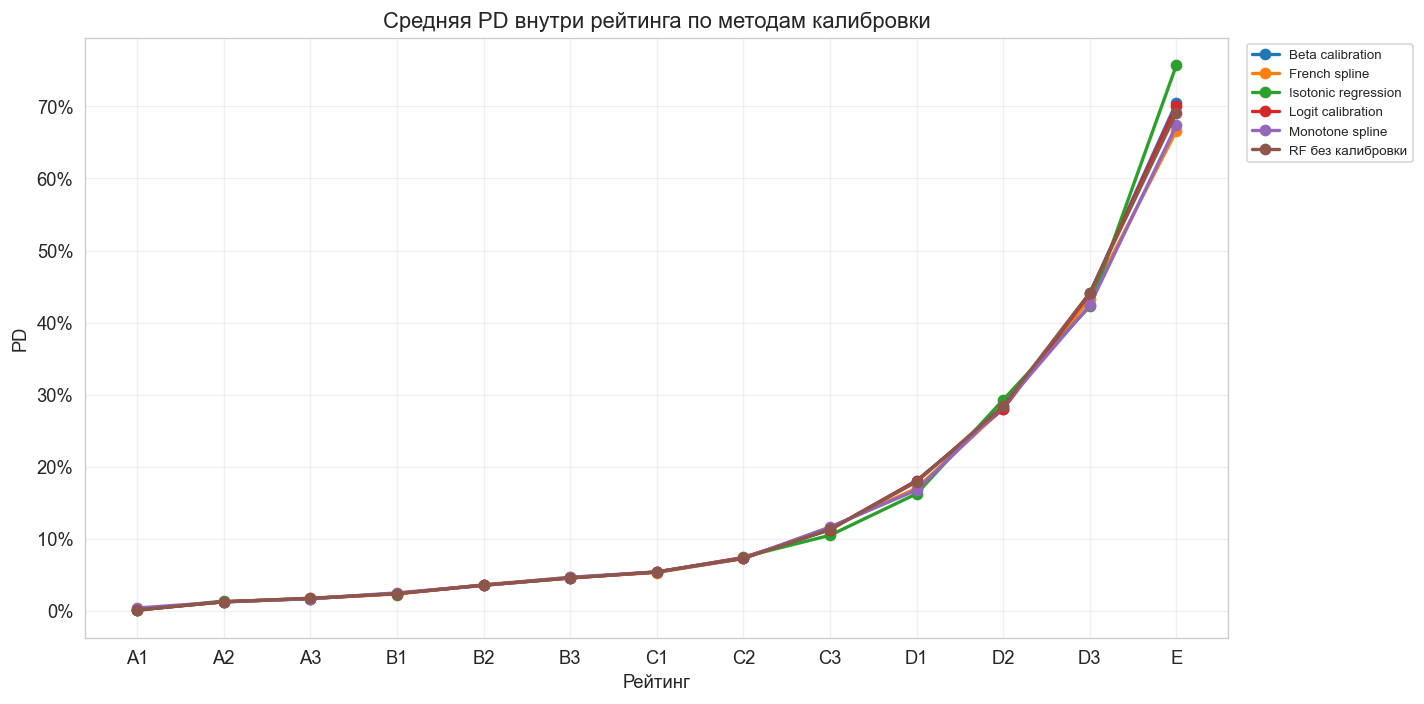

In [14]:
# =========================
# Мастер-шкала PD: сравнение методов по фиксированным PD-границам
# =========================

rating_pd_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="avg_pd")
    .reindex(MASTER_SCALE_RATINGS)
)
rating_pd_matrix_display = rating_pd_matrix.map(
    lambda x: "" if pd.isna(x) else f"{x:.2%}"
)

print("Средняя индивидуальная PD внутри рейтинга по всем методам:")
display(rating_pd_matrix_display)

fig, ax = plt.subplots(figsize=(12, 6))
for method in rating_pd_matrix.columns:
    series = rating_pd_matrix[method]
    ax.plot(
        rating_pd_matrix.index,
        series,
        marker="o",
        linewidth=2,
        label=method,
    )

ax.set_title("Средняя PD внутри рейтинга по методам калибровки")
ax.set_xlabel("Рейтинг")
ax.set_ylabel("PD")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Monotone spline vs French spline:
Mean absolute difference: 0.010349
Max absolute difference: 0.034876


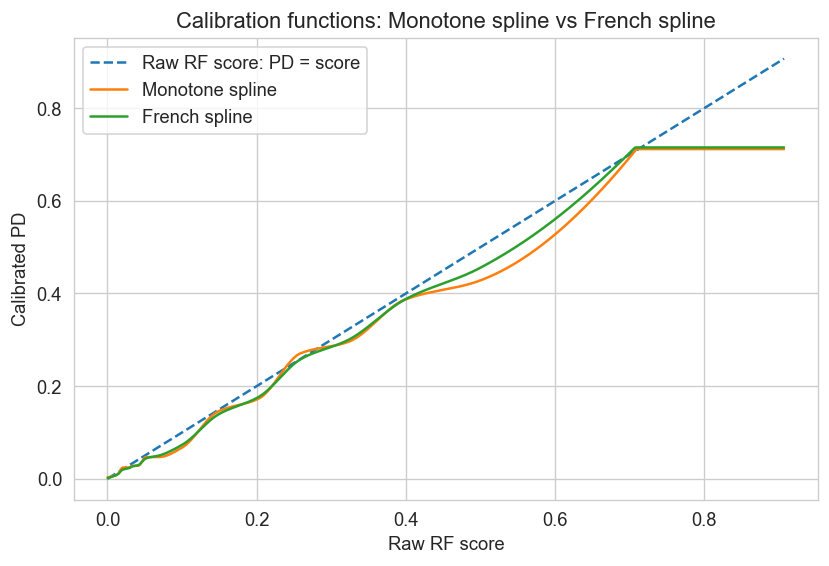

In [15]:
# Compare Monotone spline and French spline calibration functions

score_grid = np.linspace(
    max(1e-4, float(np.quantile(scores_calib, 0.001))),
    min(0.9999, float(np.quantile(scores_calib, 0.999))),
    500,
)

mono = calibrators["Monotone spline"]
french = calibrators["French spline"]

mono_pd = mono.predict(score_grid)
french_pd = french.predict(score_grid)

diff = np.abs(mono_pd - french_pd)

print("Monotone spline vs French spline:")
print(f"Mean absolute difference: {diff.mean():.6f}")
print(f"Max absolute difference: {diff.max():.6f}")

plt.figure(figsize=(8, 5))
plt.plot(score_grid, score_grid, "--", label="Raw RF score: PD = score")
plt.plot(score_grid, mono_pd, label="Monotone spline")
plt.plot(score_grid, french_pd, label="French spline")
plt.xlabel("Raw RF score")
plt.ylabel("Calibrated PD")
plt.title("Calibration functions: Monotone spline vs French spline")
plt.legend()
plt.grid(True)
plt.show()


Сравнение функций калибровки показывает, что монотонный и французский сплайн дают близкие преобразования исходного RF-score в откалиброванную PD. Это объясняется тем, что французский сплайн в текущей реализации сначала применяет логит-калибровку, а затем использует тот же механизм монотонного сплайна. Поскольку логит-калибровка в основном является монотонным преобразованием score и почти не меняет порядок наблюдений, последующее биннирование приводит к близкой итоговой кривой.

Следовательно, близкие значения Brier Score, Log-Loss, ECE и RWA для двух сплайн-методов не являются ошибкой. Они отражают то, что французский сплайн в данной реализации является скорее двухшаговой модификацией обычного монотонного сплайна, а не принципиально отдельным методом.

### Интерпретация критериев выбора метода калибровки

Один метод редко оказывается лучшим одновременно по всем критериям. Поэтому выбор метода калибровки зависит от цели анализа. Если задача состоит в минимизации ошибки вероятностного прогноза, нужно смотреть Brier Score и Log-Loss. Если важна согласованность PD с фактической частотой дефолтов по группам риска, важнее ECE, reliability diagrams и backtesting expected defaults. Если требуется простая и объяснимая модель, логит- и beta-калибровка удобнее как базовые benchmark-методы. Если нужна гладкая PD-кривая для рейтинговой шкалы, полезен монотонный сплайн.

При этом результаты OOT-проверки показывают, что лучший метод по отдельной статистической метрике не обязательно лучше по агрегированному числу дефолтов или по капитальному эффекту. В данном эксперименте калиброванные методы снизили средний уровень PD относительно RF, поэтому их экономия капитала должна интерпретироваться осторожно.

In [16]:
print("Metrics and backtesting are calculated below. Final selection table follows later.")

Metrics and backtesting are calculated below. Final selection table follows later.


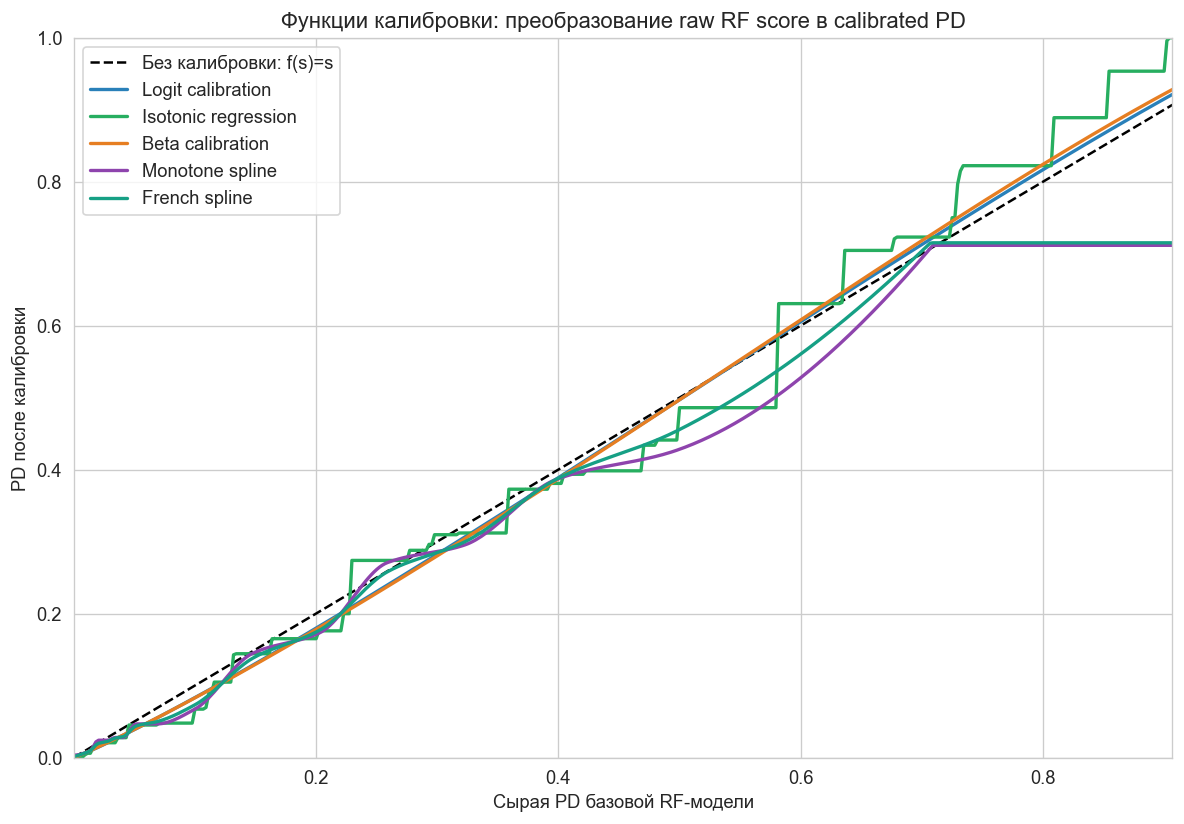

Диапазон графика ограничен 0.1% и 99.9% перцентилями calibration-скоров, чтобы редкие экстремумы не сжимали основную область.


In [17]:
score_grid = np.linspace(
    max(1e-4, float(np.quantile(scores_calib, 0.001))),
    min(0.9999, float(np.quantile(scores_calib, 0.999))),
    400,
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(score_grid, score_grid, "k--", lw=1.5, label="Без калибровки: f(s)=s")

for (name, cal), color in zip(calibrators.items(), COLORS[1:]):
    calibrated_grid = cal.predict(score_grid)
    lw = 3.0 if "сплайн" in name.lower() else 2.0
    ax.plot(score_grid, calibrated_grid, color=color, lw=lw, label=name)

ax.set_xlabel("Сырая PD базовой RF-модели")
ax.set_ylabel("PD после калибровки")
ax.set_title("Функции калибровки: преобразование raw RF score в calibrated PD")
ax.set_xlim(score_grid.min(), score_grid.max())
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("Диапазон графика ограничен 0.1% и 99.9% перцентилями calibration-скоров, чтобы редкие экстремумы не сжимали основную область.")

In [18]:
parameter_rows = []
for name, cal in calibrators.items():
    row = {"Метод": name}

    if hasattr(cal, "_model") and hasattr(cal._model, "coef_"):
        row["Параметры"] = (
            f"a={float(cal._model.coef_[0][0]):.4f}, "
            f"b={float(cal._model.intercept_[0]):.4f}"
        )
    elif hasattr(cal, "a_"):
        row["Параметры"] = (
            f"a={cal.a_:.4f}, b={cal.b_:.4f}, c={cal.c_:.4f}, "
            f"success={cal.success_}"
        )
    elif hasattr(cal, "bin_stats_") and cal.bin_stats_ is not None:
        row["Параметры"] = f"число бинов={len(cal.bin_stats_)}"
    elif hasattr(cal, "spline_stage"):
        row["Параметры"] = f"logit + spline, число бинов={len(cal.spline_stage.bin_stats_)}"
    else:
        row["Параметры"] = "непараметрический метод"

    parameter_rows.append(row)

display(pd.DataFrame(parameter_rows).set_index("Метод"))

,Параметры
Метод,
Logit calibration,"a=1.0865, b=-0.0120"
Isotonic regression,непараметрический метод
Beta calibration,"a=1.0655, b=-1.1521, c=-0.0717, success=True"
Monotone spline,число бинов=30
French spline,число бинов=30


## 6. Результаты на OOT: метрики и визуальная диагностика

**Важно для интерпретации графиков.**  
Кривые калибровки в этой версии строятся на **фиксированных бинах по всей шкале [0; 1]**.  
Это исправляет прежнюю проблему, когда при квантильной разбивке последняя точка на оси X показывала лишь **среднее значение верхнего дециля**, поэтому визуально казалось, что все методы обрываются около `0.15`, хотя фактические максимумы PD были выше.

In [19]:
results = [summary_metrics(y_test.values, scores_test, name="RF без калибровки")]
for name, probs in calibrated_probs.items():
    results.append(summary_metrics(y_test.values, probs, name=name))

df_results = pd.DataFrame(results).set_index("method")

print("Метрики на OOT-выборке, 2024 год:")
print("  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше")
print("  HL p-value                  — чем больше, тем лучше, но при большом n тест часто слишком строгий")
print("  Slope ~ 1, Intercept ~ 0    — ближе к идеальной калибровке")

df_results_ru = df_results.rename(columns={
    "brier_score": "Brier Score",
    "log_loss": "Log-Loss",
    "ece_uniform": "ECE (фикс. бины)",
    "ece_quantile": "ECE (квант. бины)",
    "hl_chi2": "HL chi2",
    "hl_p_value": "HL p-value",
    "cal_slope": "Cal. slope",
    "cal_intercept": "Cal. intercept",
})

display(
    df_results_ru.round({
        "Brier Score": 5,
        "Log-Loss": 5,
        "ECE (фикс. бины)": 5,
        "ECE (квант. бины)": 5,
        "HL chi2": 3,
        "HL p-value": 4,
        "Cal. slope": 4,
        "Cal. intercept": 4,
    })
)

disc_rows = []
all_preds = {"RF без калибровки": scores_test, **calibrated_probs}
for name, probs in all_preds.items():
    disc_rows.append(discrimination_metrics(y_test.values, probs, name=name))

df_disc = pd.DataFrame(disc_rows).set_index("method")
print("\nМетрики ранжирования (AUC / Gini / KS):")
print(df_disc.to_string())
print("\nКомментарий: строго монотонные преобразования обычно сохраняют ранжирование;")
print("изотоническая и сплайн-калибровка могут немного менять AUC/Gini из-за ties или сглаживания.")

prob_range_rows = []
for name, probs in all_preds.items():
    prob_range_rows.append({
        "method": name,
        "min_pd": np.min(probs),
        "p95_pd": np.quantile(probs, 0.95),
        "max_pd": np.max(probs),
    })

df_prob_ranges = pd.DataFrame(prob_range_rows).set_index("method")
df_prob_ranges_ru = df_prob_ranges.rename(columns={
    "min_pd": "Мин. PD",
    "p95_pd": "95-й перцентиль PD",
    "max_pd": "Макс. PD",
})
print("\nФактический диапазон PD на OOT:")
display(df_prob_ranges_ru.round(4))

Метрики на OOT-выборке, 2024 год:
  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше
  HL p-value                  — чем больше, тем лучше, но при большом n тест часто слишком строгий
  Slope ~ 1, Intercept ~ 0    — ближе к идеальной калибровке


,Brier Score,Log-Loss,ece,ECE (фикс. бины),ECE (квант. бины),HL chi2,HL p-value,Cal. slope,Cal. intercept
method,,,,,,,,,
RF без калибровки,0.06097,0.19647,0.00988,0.00936,0.00988,14.105,0.0791,1.1296,0.2560
Logit calibration,0.06108,0.19676,0.01371,0.01400,0.01371,21.941,0.0050,1.0397,0.2684
Isotonic regression,0.06139,0.19716,0.01316,0.01427,0.01316,23.810,0.0002,1.0170,0.2415
Beta calibration,0.06107,0.19671,0.01380,0.01381,0.01380,21.986,0.0049,1.0409,0.2707
Monotone spline,0.06228,0.20101,0.01990,0.01614,0.01990,50.304,0.0000,1.1728,0.4686
French spline,0.06195,0.19948,0.01783,0.01597,0.01783,38.522,0.0000,1.1196,0.4002



Метрики ранжирования (AUC / Gini / KS):
                     auc_roc    gini  ks_stat
method                                       
RF без калибровки     0.9284  0.8568   0.7198
Logit calibration     0.9284  0.8568   0.7198
Isotonic regression   0.9279  0.8559   0.7183
Beta calibration      0.9284  0.8568   0.7198
Monotone spline       0.9284  0.8568   0.7198
French spline         0.9284  0.8568   0.7198

Комментарий: строго монотонные преобразования обычно сохраняют ранжирование;
изотоническая и сплайн-калибровка могут немного менять AUC/Gini из-за ties или сглаживания.

Фактический диапазон PD на OOT:


,Мин. PD,95-й перцентиль PD,Макс. PD
method,,,
RF без калибровки,0.0003,0.5154,0.9383
Logit calibration,0.0001,0.5138,0.9501
Isotonic regression,0.0000,0.4861,1.0000
Beta calibration,0.0001,0.5142,0.9556
Monotone spline,0.0035,0.4386,0.7116
French spline,0.0010,0.4693,0.7151


### Backtesting методов на исторической структуре OOT-портфеля

После калибровки сравниваем методы не только одной строкой метрик, но и на уровне `2024 × рейтинг`. Это отвечает на вопрос, какой метод лучше сохраняет риск-профиль портфеля по разным рейтингам.


In [20]:
df_test = df.loc[y_test.index].copy()
oot_predictions = {"RF без калибровки": scores_test, **calibrated_probs}

method_summary = method_portfolio_summary(df_test, oot_predictions)
rating_method_panel = compare_methods_by_historical_panel(df_test, oot_predictions)

print("Агрегированный итог по OOT-портфелю, 2024:")
display(
    method_summary[[
        "avg_pd",
        "defaults",
        "expected_defaults",
        "default_gap",
        "calibration_ratio",
    ]]
    .style.format({
        "avg_pd": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "default_gap": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)

print("Детализация по рейтингу на OOT-периоде:")
rating_view_cols = [
    "method",
    "origination_year",
    "rating",
    "n_obs",
    "portfolio_count_share",
    "avg_pd",
    "pd_min",
    "pd_max",
    "observed_default_rate",
    "expected_defaults",
    "defaults",
    "calibration_ratio",
]
display(
    rating_method_panel[rating_view_cols]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "avg_pd": "{:.2%}",
        "pd_min": "{:.2%}",
        "pd_max": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)


Агрегированный итог по OOT-портфелю, 2024:

,avg_pd,defaults,expected_defaults,default_gap,calibration_ratio
method,,,,,
RF без калибровки,10.46%,713.000000,666.77,46.23,1.07
Logit calibration,9.86%,713.000000,628.48,84.52,1.13
Isotonic regression,9.87%,713.000000,629.13,83.87,1.13
Beta calibration,9.86%,713.000000,628.47,84.53,1.13
Monotone spline,9.58%,713.000000,610.16,102.84,1.17
French spline,9.59%,713.000000,611.23,101.77,1.17


Детализация по рейтингу на OOT-периоде:


,method,origination_year,rating,n_obs,portfolio_count_share,avg_pd,pd_min,pd_max,observed_default_rate,expected_defaults,defaults,calibration_ratio
0,RF без калибровки,2024,A,2379,37.3%,0.12%,0.03%,2.26%,0.00%,2.97,0,0.00
1,RF без калибровки,2024,B,2361,37.1%,3.65%,0.14%,45.94%,2.88%,86.15,68,0.79
2,RF без калибровки,2024,C,1506,23.6%,32.33%,2.47%,85.81%,35.52%,486.90,535,1.10
3,RF без калибровки,2024,D,126,2.0%,72.02%,34.15%,93.83%,87.30%,90.75,110,1.21
4,Logit calibration,2024,A,2379,37.3%,0.07%,0.01%,1.62%,0.00%,1.71,0,0.00
5,Logit calibration,2024,B,2361,37.1%,2.83%,0.08%,45.29%,2.88%,66.78,68,1.02
6,Logit calibration,2024,C,1506,23.6%,31.07%,1.78%,87.47%,35.52%,467.90,535,1.14
7,Logit calibration,2024,D,126,2.0%,73.09%,32.62%,95.01%,87.30%,92.09,110,1.19
8,Isotonic regression,2024,A,2379,37.3%,0.02%,0.00%,2.07%,0.00%,0.53,0,0.00
9,Isotonic regression,2024,B,2361,37.1%,2.78%,0.02%,39.84%,2.88%,65.58,68,1.04


### Как выбирать метод калибровки

Один метод редко является лучшим по всем критериям одновременно. Поэтому ниже метод выбирается не только по статистической метрике, но и по практической роли в банковской модели.

In [21]:
selection_table = pd.DataFrame([
    {
        "Сценарий выбора": "Минимизировать Brier / Log-Loss",
        "Что смотреть": "Brier Score, Log-Loss",
        "Типичный кандидат": df_results["brier_score"].idxmin(),
        "Комментарий": "Лучше для чистого качества вероятностного прогноза.",
    },
    {
        "Сценарий выбора": "Минимизировать ошибку калибровки",
        "Что смотреть": "ECE на квантильных и фиксированных бинах",
        "Типичный кандидат": df_results["ece_quantile"].idxmin(),
        "Комментарий": "Полезно для reliability diagrams и backtesting PD.",
    },
    {
        "Сценарий выбора": "Сохранить простоту и интерпретируемость",
        "Что смотреть": "Стабильность, slope/intercept, governance",
        "Типичный кандидат": "Логит-калибровка / Бета-калибровка",
        "Комментарий": "Хорошие базовые benchmark-методы.",
    },
    {
        "Сценарий выбора": "Получить гладкую PD-кривую",
        "Что смотреть": "ECE, графики, отсутствие ступеней",
        "Типичный кандидат": "Монотонный сплайн / Французский сплайн",
        "Комментарий": "Удобно для банковской master scale и презентации калибровочной функции.",
    },
    {
        "Сценарий выбора": "Оценить capital impact",
        "Что смотреть": "RWA_capital, regulatory RWA, H1 if keep RF UL capital",
        "Типичный кандидат": "Определяется отдельно в RWA-блоке",
        "Комментарий": "Лучший по Brier метод не обязан давать минимальный капитал.",
    },
])

display(selection_table)

,Сценарий выбора,Что смотреть,Типичный кандидат,Комментарий
0,Минимизировать Brier / Log-Loss,"Brier Score, Log-Loss",RF без калибровки,Лучше для чистого качества вероятностного прог...
1,Минимизировать ошибку калибровки,ECE на квантильных и фиксированных бинах,RF без калибровки,Полезно для reliability diagrams и backtesting...
2,Сохранить простоту и интерпретируемость,"Стабильность, slope/intercept, governance",Логит-калибровка / Бета-калибровка,Хорошие базовые benchmark-методы.
3,Получить гладкую PD-кривую,"ECE, графики, отсутствие ступеней",Монотонный сплайн / Французский сплайн,Удобно для банковской master scale и презентац...
4,Оценить capital impact,"RWA_capital, regulatory RWA, H1 if keep RF UL ...",Определяется отдельно в RWA-блоке,Лучший по Brier метод не обязан давать минимал...


### Backtesting методов на исторической структуре OOT-портфеля

In [22]:
# =========================
# Диагностическая intercept recalibration
# =========================
# Цель: проверить, связана ли ошибка OOT-бэктеста
# преимущественно со сдвигом общего уровня PD.
#
# ВАЖНО:
# Здесь target_pd = фактическая дефолтность OOT.
# Это диагностический / oracle-сценарий, а не честная production-настройка.
# В реальной задаче target_pd должен задаваться заранее:
# например, из макропрогноза, исторической дефолтности или risk appetite.

from scipy.optimize import brentq
from scipy.special import expit

EPS_PD = 1e-6


def logit_transform(p):
    p = np.clip(np.asarray(p, dtype=float), EPS_PD, 1 - EPS_PD)
    return np.log(p / (1 - p))


def intercept_recalibrate_to_target(pd_values, target_pd, sample_weight=None):
    """
    Сдвигает PD на logit-шкале:

        logit(PD_new) = logit(PD_old) + delta

    Подбирает delta так, чтобы средняя PD совпала с target_pd.
    Ранжирование заемщиков при этом сохраняется.
    """

    p = np.clip(np.asarray(pd_values, dtype=float), EPS_PD, 1 - EPS_PD)

    if sample_weight is None:
        weights = np.ones(len(p), dtype=float)
    else:
        weights = np.asarray(sample_weight, dtype=float)

    logits = logit_transform(p)

    def objective(delta):
        shifted_pd = expit(logits + delta)
        return np.average(shifted_pd, weights=weights) - target_pd

    delta = brentq(objective, -50, 50)
    p_new = np.clip(expit(logits + delta), EPS_PD, 1 - EPS_PD)

    return p_new, float(delta)


# Базовые прогнозы на OOT
base_predictions = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

# Диагностический target: фактическая дефолтность OOT
# В production-логике это значение нельзя брать из y_test.
TARGET_PD_INTERCEPT = float(y_test.mean())

intercept_adjusted_probs = {}
intercept_rows = []

for name, probs in base_predictions.items():
    probs_adj, delta = intercept_recalibrate_to_target(
        probs,
        target_pd=TARGET_PD_INTERCEPT,
        sample_weight=np.ones(len(y_test), dtype=float),
    )

    new_name = f"{name} + intercept"
    intercept_adjusted_probs[new_name] = probs_adj

    intercept_rows.append({
        "method": name,
        "target_default_rate": TARGET_PD_INTERCEPT,
        "avg_pd_before": float(np.mean(probs)),
        "avg_pd_after": float(np.mean(probs_adj)),
        "delta_logit": delta,
        "actual_defaults": int(y_test.sum()),
        "expected_defaults_before": float(np.sum(probs)),
        "expected_defaults_after": float(np.sum(probs_adj)),
        "gap_before": float(y_test.sum() - np.sum(probs)),
        "gap_after": float(y_test.sum() - np.sum(probs_adj)),
    })

df_intercept_shift = pd.DataFrame(intercept_rows).set_index("method")

display(
    df_intercept_shift.style.format({
        "target_default_rate": "{:.2%}",
        "avg_pd_before": "{:.2%}",
        "avg_pd_after": "{:.2%}",
        "delta_logit": "{:.4f}",
        "actual_defaults": "{:.0f}",
        "expected_defaults_before": "{:.2f}",
        "expected_defaults_after": "{:.2f}",
        "gap_before": "{:.2f}",
        "gap_after": "{:.2f}",
    })
)

,target_default_rate,avg_pd_before,avg_pd_after,delta_logit,actual_defaults,expected_defaults_before,expected_defaults_after,gap_before,gap_after
method,,,,,,,,,
RF без калибровки,11.19%,10.46%,11.19%,0.1142,713,666.77,713.00,46.23,-0.00
Logit calibration,11.19%,9.86%,11.19%,0.2222,713,628.48,713.00,84.52,-0.00
Isotonic regression,11.19%,9.87%,11.19%,0.2216,713,629.13,713.00,83.87,0.00
Beta calibration,11.19%,9.86%,11.19%,0.2227,713,628.47,713.00,84.53,-0.00
Monotone spline,11.19%,9.58%,11.19%,0.2526,713,610.16,713.00,102.84,-0.00
French spline,11.19%,9.59%,11.19%,0.2561,713,611.23,713.00,101.77,-0.00


In [23]:
# =========================
# Сравнение статистических метрик до и после intercept recalibration
# =========================

metric_rows = []

for name, probs in base_predictions.items():
    before = summary_metrics(y_test.values, probs, name=name)
    before["base_method"] = name
    before["variant"] = "до intercept"

    after_probs = intercept_adjusted_probs[f"{name} + intercept"]
    after = summary_metrics(y_test.values, after_probs, name=f"{name} + intercept")
    after["base_method"] = name
    after["variant"] = "после intercept"

    metric_rows.extend([before, after])

df_intercept_metrics = pd.DataFrame(metric_rows)

metric_cols = [
    "brier_score",
    "log_loss",
    "ece_uniform",
    "ece_quantile",
    "hl_chi2",
    "hl_p_value",
    "cal_slope",
    "cal_intercept",
]

display(
    df_intercept_metrics
    .set_index(["base_method", "variant"])[metric_cols]
    .style.format({
        "brier_score": "{:.5f}",
        "log_loss": "{:.5f}",
        "ece_uniform": "{:.5f}",
        "ece_quantile": "{:.5f}",
        "hl_chi2": "{:.3f}",
        "hl_p_value": "{:.4f}",
        "cal_slope": "{:.4f}",
        "cal_intercept": "{:.4f}",
    })
)

In [24]:
# =========================
# Проверка сохранения ранжирования
# =========================

disc_rows = []

for name, probs in base_predictions.items():
    before = discrimination_metrics(y_test.values, probs, name=name)
    before["base_method"] = name
    before["variant"] = "до intercept"

    after_probs = intercept_adjusted_probs[f"{name} + intercept"]
    after = discrimination_metrics(y_test.values, after_probs, name=f"{name} + intercept")
    after["base_method"] = name
    after["variant"] = "после intercept"

    disc_rows.extend([before, after])

df_intercept_disc = pd.DataFrame(disc_rows)

display(
    df_intercept_disc
    .set_index(["base_method", "variant"])[["auc_roc", "gini", "ks_stat"]]
    .style.format({
        "auc_roc": "{:.4f}",
        "gini": "{:.4f}",
        "ks_stat": "{:.4f}",
    })
)

In [25]:
# =========================
# Backtesting expected defaults после intercept recalibration
# =========================

df_test = df.loc[y_test.index].copy()

oot_predictions_intercept_experiment = {
    **base_predictions,
    **intercept_adjusted_probs,
}

method_summary_intercept = method_portfolio_summary(
    df_test,
    oot_predictions_intercept_experiment,
)

method_summary_intercept["abs_default_gap"] = method_summary_intercept["default_gap"].abs()

display(
    method_summary_intercept[[
        "avg_pd",
        "defaults",
        "expected_defaults",
        "default_gap",
        "abs_default_gap",
        "calibration_ratio",
    ]]
    .sort_values("abs_default_gap")
    .style.format({
        "avg_pd": "{:.2%}",
        "defaults": "{:.0f}",
        "expected_defaults": "{:.2f}",
        "default_gap": "{:.2f}",
        "abs_default_gap": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)

,avg_pd,defaults,expected_defaults,default_gap,abs_default_gap,calibration_ratio
method,,,,,,
Monotone spline + intercept,11.19%,713,713.00,-0.00,0.00,1.00
French spline + intercept,11.19%,713,713.00,-0.00,0.00,1.00
Beta calibration + intercept,11.19%,713,713.00,-0.00,0.00,1.00
Logit calibration + intercept,11.19%,713,713.00,-0.00,0.00,1.00
RF без калибровки + intercept,11.19%,713,713.00,-0.00,0.00,1.00
Isotonic regression + intercept,11.19%,713,713.00,0.00,0.00,1.00
RF без калибровки,10.46%,713,666.77,46.23,46.23,1.07
Isotonic regression,9.87%,713,629.13,83.87,83.87,1.13
Logit calibration,9.86%,713,628.48,84.52,84.52,1.13


Дополнительный эксперимент с intercept recalibration подтвердил, что проблема OOT-бэктеста во многом связана не с потерей ранжирующей способности модели, а со сдвигом базового уровня дефолтности в тестовом периоде. После сдвига PD на logit-шкале средний прогнозный PD был приведен к фактической дефолтности OOT, при этом ранжирующие метрики практически не изменились. Следовательно, исходные калибраторы сохраняют способность различать заемщиков по уровню риска, но требуют корректировки общего уровня PD при изменении макроэкономического режима.

### Эффект калибровки на резервы, RWA и требуемый капитал

После статистического сравнения каждая версия PD переводится в прикладные показатели: **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%** и **Capital_true**. Это позволяет оценить не только качество калибровки как статистической процедуры, но и её влияние на капитальную нагрузку портфеля.

Для чистоты сравнения используется фиксированное допущение **EAD = 1 000 000** на каждое наблюдение и **LGD = 40%**. Поэтому различия между методами интерпретируются как эффект именно от калиброванной **PD**, а не от разного размера экспозиции.

Дополнительно рассчитывается, сколько капитала можно высвободить относительно **сырых PD** при целевом нормативе **H1 = 8%**, а также каким станет фактический **H1**, если сохранить капитал, достаточный для некалиброванной базовой модели.

каждое наблюдение OOT-портфеля → своя PD → распределение PD по методу

In [26]:
pred_map = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

capital_assumptions = master_scale_assumptions

# Mentor-format 845-P calculation for every PD method on the same 2024 portfolio.
df_rwa = compare_845p_capital_by_method(
    pred_map,
    defaults=y_test.values.astype(float),
    assumptions=capital_assumptions,
    baseline_method="RF без калибровки",
)

base_ul_capital_rf = df_rwa.loc["RF без калибровки", "total_rwa_capital"]

# В формуле 845-П RWA_capital - это UL-капитал. Для H1 нужен знаменатель RWA,
# поэтому переводим UL-капитал в регуляторный RWA через норматив 8%.
df_rwa["regulatory_rwa"] = df_rwa["total_regulatory_rwa"]
df_rwa["h1_if_keep_rf_ul_capital"] = base_ul_capital_rf / df_rwa["regulatory_rwa"]
df_rwa["h1_deviation_vs_8pct"] = (
    df_rwa["h1_if_keep_rf_ul_capital"] - capital_assumptions.capital_ratio
)

# Backward-compatible names for later summary cells.
df_rwa["h1_0_if_keep_rf_capital"] = df_rwa["h1_if_keep_rf_ul_capital"]
df_rwa["h1_0_uplift_vs_norm"] = df_rwa["h1_deviation_vs_8pct"]

df_rwa = df_rwa.sort_values("total_required_capital")

print(f"Fixed EAD per observation = {capital_assumptions.ead:,.0f}")
print(f"LGD = {capital_assumptions.lgd:.0%}")
print(f"M = {capital_assumptions.maturity_years:.1f}")
print()
print("845-P calculation logic:")
print("EL / Reserves = PD * LGD * EAD")
print("UL / RWA_capital = EAD * LGD * (conditional PD - PD) * maturity adjustment")
print("Regulatory RWA = RWA_capital / 8%")
print("Capital_true = Reserves + RWA_capital for non-defaulted observations")
print("Capital_true = LGD * EAD for defaulted observations")

display_cols = [
    "avg_pd",
    "total_ead",
    "total_expected_loss",
    "total_unexpected_loss_capital",
    "total_rwa_capital",
    "total_regulatory_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    "capital_saving_vs_baseline_pct",
    "h1_if_keep_rf_ul_capital",
    "h1_deviation_vs_8pct",
]

display(
    df_rwa[display_cols]
    .style.format({
        "avg_pd": "{:.2%}",
        "total_ead": "{:,.0f}",
        "total_expected_loss": "{:,.0f}",
        "total_unexpected_loss_capital": "{:,.0f}",
        "total_rwa_capital": "{:,.0f}",
        "total_regulatory_rwa": "{:,.0f}",
        "total_required_capital": "{:,.0f}",
        "rwa_saving_vs_baseline_pct": "{:.2%}",
        "capital_saving_vs_baseline_pct": "{:.2%}",
        "h1_if_keep_rf_ul_capital": "{:.2%}",
        "h1_deviation_vs_8pct": "{:.2%}",
    })
)


Fixed EAD per observation = 1,000,000
LGD = 40%
M = 2.5

845-P calculation logic:
EL / Reserves = PD * LGD * EAD
UL / RWA_capital = EAD * LGD * (conditional PD - PD) * maturity adjustment
Regulatory RWA = RWA_capital / 8%
Capital_true = Reserves + RWA_capital for non-defaulted observations
Capital_true = LGD * EAD for defaulted observations


,avg_pd,total_ead,total_expected_loss,total_unexpected_loss_capital,total_rwa_capital,total_regulatory_rwa,total_required_capital,rwa_saving_vs_baseline_pct,capital_saving_vs_baseline_pct,h1_if_keep_rf_ul_capital,h1_deviation_vs_8pct
method,,,,,,,,,,,
Isotonic regression,9.88%,"6,372,000,000","251,780,762","471,458,132","471,458,132","5,893,226,654","792,436,690",9.73%,7.27%,8.86%,0.86%
Logit calibration,9.86%,"6,372,000,000","251,421,124","486,663,145","486,663,145","6,083,289,313","807,026,893",6.82%,5.56%,8.59%,0.59%
Beta calibration,9.86%,"6,372,000,000","251,410,129","488,365,938","488,365,938","6,104,574,219","808,873,592",6.49%,5.34%,8.56%,0.56%
French spline,9.59%,"6,372,000,000","244,491,621","528,046,021","528,046,021","6,600,575,265","843,481,188",-1.11%,1.29%,7.91%,-0.09%
RF без калибровки,10.46%,"6,372,000,000","266,709,672","522,255,992","522,255,992","6,528,199,898","854,535,602",0.00%,0.00%,8.00%,0.00%
Monotone spline,9.58%,"6,372,000,000","244,063,569","568,789,913","568,789,913","7,109,873,913","884,811,683",-8.91%,-3.54%,7.35%,-0.65%


### Расчет по формуле 845-П в формате ментора

Ниже сохранен рекомендованный ментором блок расчета. Перед ним создается `data_ocp` с теми именами колонок, которые ожидает исходный код: `FRAT_FINAL_PD`, `EAD`, `DEFAULT_DURING_NEXT_YEAR`. В качестве `FRAT_FINAL_PD` используется метод с минимальным Brier Score на тестовой выборке, а не заранее выбранный сплайн.

In [27]:
final_pd_method = df_results["brier_score"].idxmin()
print(f"Финальная PD для расчета 845-П: {final_pd_method}")

final_pd_values = scores_test if final_pd_method == "RF без калибровки" else calibrated_probs[final_pd_method]

data_ocp = calculate_845p_capital(
    final_pd_values,
    defaults=y_test.values.astype(float),
    assumptions=master_scale_assumptions,
)

# Используем формулы из 845-П
data_ocp.head(3)


Финальная PD для расчета 845-П: RF без калибровки


,FRAT_FINAL_PD,EAD,DEFAULT_DURING_NEXT_YEAR,Reserves,R,RWA_capital,Capital_true
0,0.000607,1000000.0,0.0,242.773921,0.236413,15696.021143,15938.795064
1,0.016041,1000000.0,0.0,6416.488939,0.173808,76628.190952,83044.679890
2,0.000577,1000000.0,0.0,230.645542,0.236590,15222.027464,15452.673006


### Ограничения RWA-блока

Расчет ниже нужен для оценки чувствительности капитала к калиброванной PD, а не для полноценной регуляторной отчетности.

Ключевые упрощения:

- используется Basel-style IRB формула для иллюстрации, а не полный production IRB контур банка;
- `EAD`, `LGD` и `M` фиксированы, чтобы изолировать именно эффект PD;
- не моделируются downturn LGD, CRM, guarantees, collateral, defaulted assets и сегментные регуляторные нюансы;
- синтетический портфель нужен для демонстрации методологии, а не для оценки реального банка.

Поэтому результаты RWA следует читать как **сравнительный эффект калибровки**, а не как абсолютный норматив капитала.

#### Визуализация эффекта на RWA и капитал

Ниже показано, как различия в калиброванной `PD` отражаются на:
- резервах;
- `RWA_capital`, то есть UL-капитале по формуле 845-П;
- регуляторном `RWA = RWA_capital / 8%`;
- экономии капитала относительно сырых `PD`;
- отклонении `H1` от 8%, если сохранить UL-капитал RF без калибровки.

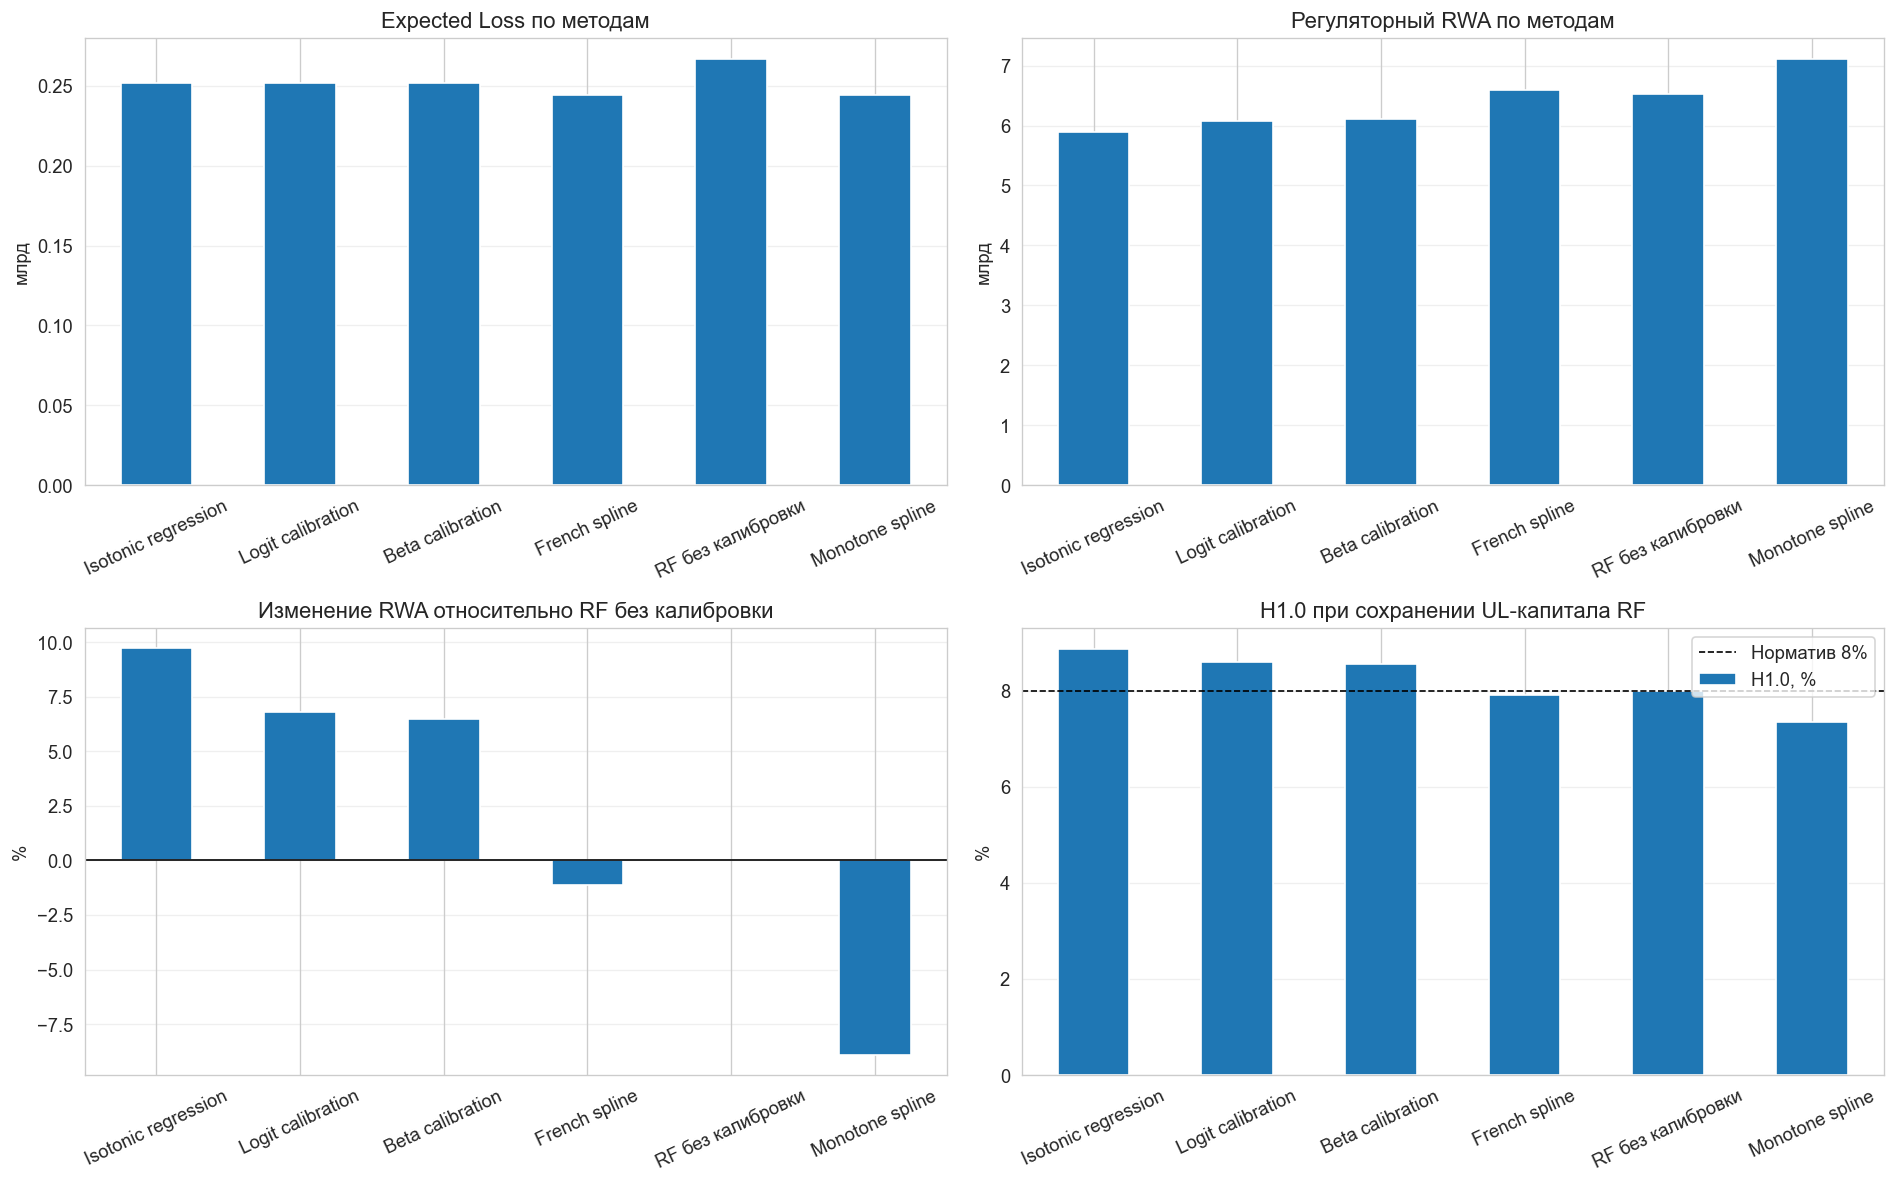

In [28]:
# =========================
# Компактная визуализация capital impact
# =========================

plot_df = df_rwa.reset_index().copy()

plot_df["EL, млрд"] = plot_df["total_expected_loss"] / 1_000_000_000
plot_df["UL-капитал, млрд"] = plot_df["total_rwa_capital"] / 1_000_000_000
plot_df["Регуляторный RWA, млрд"] = plot_df["total_regulatory_rwa"] / 1_000_000_000
plot_df["Изм. RWA vs RF, %"] = 100 * plot_df["regulatory_rwa_saving_vs_baseline_pct"]
plot_df["Н1.0, %"] = 100 * plot_df["h1_0_if_keep_rf_capital"]

# Если хочешь дополнительно видеть риск-вес портфеля:
plot_df["RWA / EAD, %"] = 100 * (plot_df["total_regulatory_rwa"] / plot_df["total_ead"])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Expected Loss
plot_df.plot(
    x="method",
    y="EL, млрд",
    kind="bar",
    ax=axes[0, 0],
    legend=False,
    rot=25,
    title="Expected Loss по методам"
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("млрд")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. Regulatory RWA
plot_df.plot(
    x="method",
    y="Регуляторный RWA, млрд",
    kind="bar",
    ax=axes[0, 1],
    legend=False,
    rot=25,
    title="Регуляторный RWA по методам"
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("млрд")
axes[0, 1].grid(axis="y", alpha=0.3)

# 3. Изменение RWA vs RF
plot_df.plot(
    x="method",
    y="Изм. RWA vs RF, %",
    kind="bar",
    ax=axes[1, 0],
    legend=False,
    rot=25,
    title="Изменение RWA относительно RF без калибровки"
)
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("%")
axes[1, 0].grid(axis="y", alpha=0.3)

# 4. Н1.0 при сохранении UL-капитала RF
plot_df.plot(
    x="method",
    y="Н1.0, %",
    kind="bar",
    ax=axes[1, 1],
    legend=False,
    rot=25,
    title="Н1.0 при сохранении UL-капитала RF"
)
axes[1, 1].axhline(
    100 * capital_assumptions.capital_ratio,
    color="black",
    lw=1,
    linestyle="--",
    label="Норматив 8%"
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("%")
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 7. Оценка устойчивости результатов

При близких значениях метрик точечные оценки сами по себе могут вводить в заблуждение. Поэтому устойчивость результатов проверяется через **bootstrap confidence intervals** для Brier Score и AUC.

Если доверительные интервалы методов существенно перекрываются, это означает, что различия между ними малы и не дают оснований объявлять одного явного победителя только по одной точечной метрике.

In [29]:
from sklearn.metrics import roc_auc_score

boot_rows = []

print("Bootstrap 95% CI (1000 итераций) на OOT Test...")
print(f"{'Метод':<28} {'Brier':>7}  {'95% CI Brier':>18}  {'AUC':>7}  {'95% CI AUC':>18}")
print("-" * 85)

for name, probs in all_preds.items():
    ci_brier = bootstrap_ci(y_test.values, probs, brier_score,   n_iter=1000, random_state=42)
    ci_auc   = bootstrap_ci(y_test.values, probs, roc_auc_score, n_iter=1000, random_state=42)

    boot_rows.append({
        "method": name,
        "brier_point": ci_brier["point_estimate"],
        "brier_ci_lower": ci_brier["ci_lower"],
        "brier_ci_upper": ci_brier["ci_upper"],
        "auc_point": ci_auc["point_estimate"],
        "auc_ci_lower": ci_auc["ci_lower"],
        "auc_ci_upper": ci_auc["ci_upper"],
    })

    print(
        f"{name:<28} "
        f"{ci_brier['point_estimate']:>7.5f}  "
        f"[{ci_brier['ci_lower']:.5f}, {ci_brier['ci_upper']:.5f}]  "
        f"{ci_auc['point_estimate']:>7.4f}  "
        f"[{ci_auc['ci_lower']:.4f}, {ci_auc['ci_upper']:.4f}]"
    )

df_boot = pd.DataFrame(boot_rows).set_index("method")

print("\nИнтерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.")


Bootstrap 95% CI (1000 итераций) на OOT Test...
Метод                          Brier        95% CI Brier      AUC          95% CI AUC
-------------------------------------------------------------------------------------


RF без калибровки            0.06097  [0.05724, 0.06497]   0.9284  [0.9202, 0.9357]


Logit calibration            0.06108  [0.05725, 0.06516]   0.9284  [0.9202, 0.9357]


Isotonic regression          0.06139  [0.05752, 0.06543]   0.9279  [0.9196, 0.9354]


Beta calibration             0.06107  [0.05722, 0.06516]   0.9284  [0.9202, 0.9357]


Monotone spline              0.06228  [0.05835, 0.06632]   0.9284  [0.9203, 0.9358]


French spline                0.06195  [0.05811, 0.06601]   0.9284  [0.9202, 0.9357]

Интерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.


### Анализ по полной шкале вероятностей

Ниже калибровка и распределение PD показаны **на всей шкале [0; 1]**, а не только в той области, где сосредоточена основная масса наблюдений.  
Дополнительно для каждого метода строится таблица фиксированных биннов `[0.0–0.1], …, [0.9–1.0]`, чтобы увидеть, **как именно модель распределяет наблюдения и дефолты по всей шкале риска**.


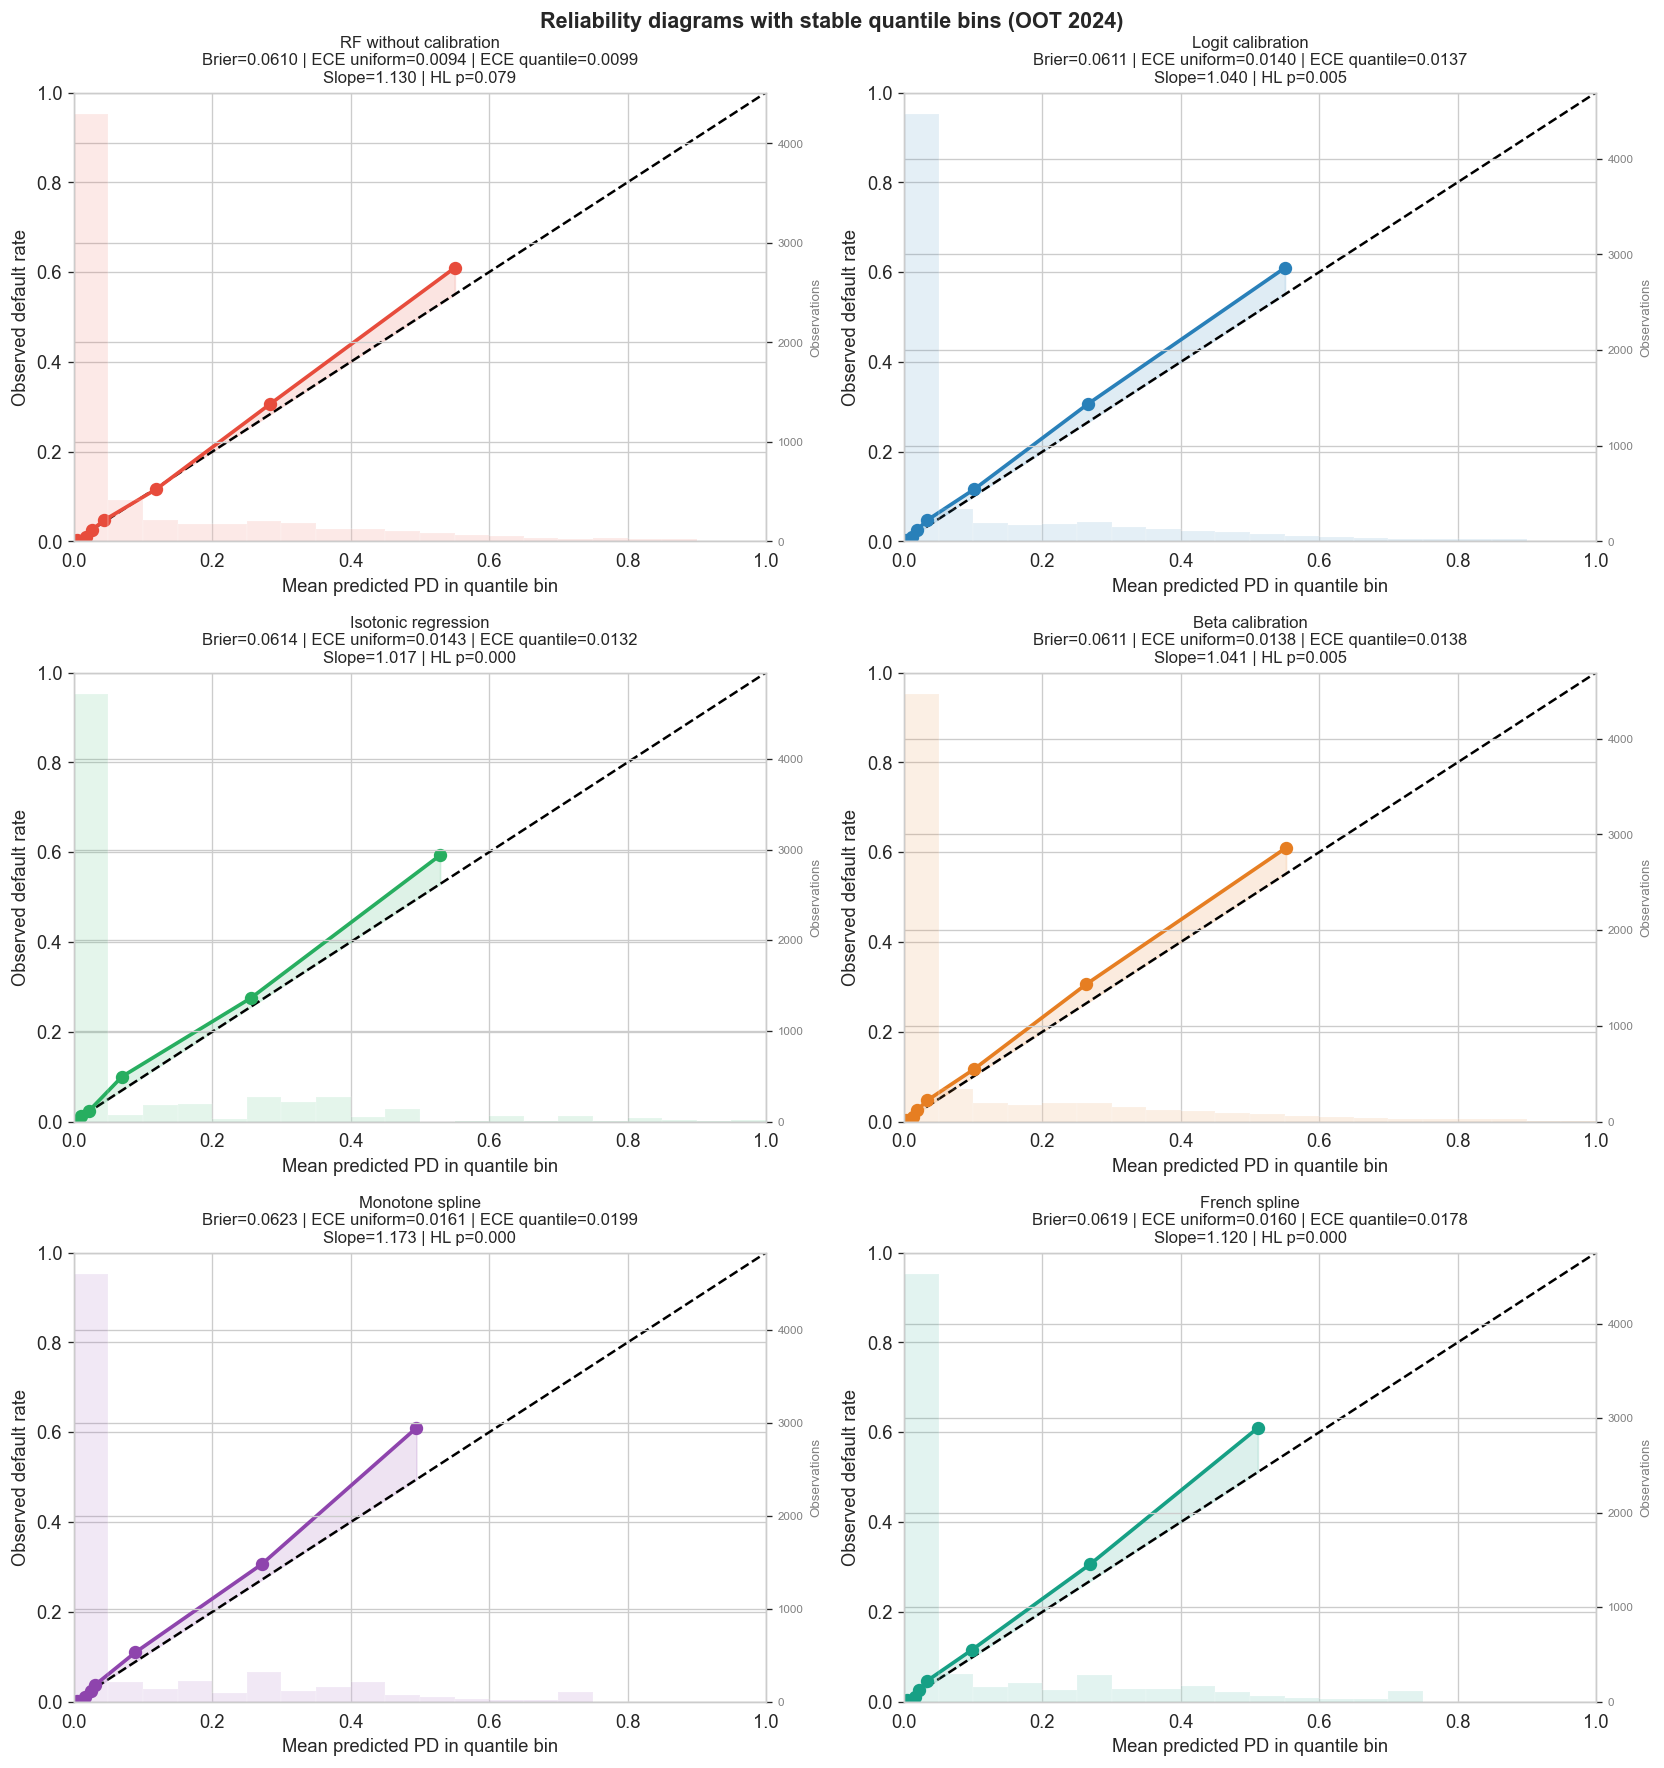

Fixed-bin diagnostics on the full [0, 1] scale. Sparse bins are not used as connected reliability points:

RF without calibration
          bin    n  share  avg_pd  default_rate  defaults  is_sparse
(-0.001, 0.1] 4717  74.03  0.0169        0.0155        73      False
   (0.1, 0.2]  392   6.15  0.1471        0.1505        59      False
   (0.2, 0.3]  378   5.93  0.2528        0.2778       105      False
   (0.3, 0.4]  312   4.90  0.3453        0.3750       117      False
   (0.4, 0.5]  227   3.56  0.4470        0.4581       104      False
   (0.5, 0.6]  151   2.37  0.5452        0.6225        94      False
   (0.6, 0.7]   89   1.40  0.6450        0.6742        60      False
   (0.7, 0.8]   57   0.89  0.7534        0.9474        54      False
   (0.8, 0.9]   42   0.66  0.8463        0.9524        40      False
   (0.9, 1.0]    7   0.11  0.9181        1.0000         7       True

Logit calibration
          bin    n  share  avg_pd  default_rate  defaults  is_sparse
(-0.001, 0.1] 4806  75.

In [30]:
all_methods = {"RF without calibration": scores_test, **calibrated_probs}

MIN_RELIABILITY_BIN_N = 30
n_methods = len(all_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (name, probs) in enumerate(all_methods.items()):
    ax = axes[i]
    curve_table = calibration_bin_table(
        y_test.values,
        probs,
        n_bins=10,
        strategy="quantile",
        min_count=MIN_RELIABILITY_BIN_N,
    )
    plot_table = curve_table.loc[~curve_table["is_sparse"]].copy()
    m = summary_metrics(y_test.values, probs)

    ax.plot([0, 1], [0, 1], "k--", lw=1.5)
    ax.plot(
        plot_table["avg_pd"],
        plot_table["default_rate"],
        "o-",
        color=COLORS[i],
        lw=2.2,
        ms=7,
    )
    ax.fill_between(
        plot_table["avg_pd"],
        plot_table["avg_pd"],
        plot_table["default_rate"],
        alpha=0.15,
        color=COLORS[i],
    )

    sparse_table = curve_table.loc[curve_table["is_sparse"]]
    if not sparse_table.empty:
        ax.scatter(
            sparse_table["avg_pd"],
            sparse_table["default_rate"],
            s=70,
            facecolors="none",
            edgecolors=COLORS[i],
            linewidths=1.8,
            label=f"sparse bins n < {MIN_RELIABILITY_BIN_N}",
        )
        ax.legend(loc="upper left", fontsize=8)

    ax2 = ax.twinx()
    ax2.hist(probs, bins=np.linspace(0, 1, 21), alpha=0.12, color=COLORS[i])
    ax2.set_ylabel("Observations", fontsize=8, color="gray")
    ax2.tick_params(axis="y", labelsize=7, labelcolor="gray")

    subtitle = (
        f'Brier={m["brier_score"]:.4f} | ECE uniform={m["ece_uniform"]:.4f} | ECE quantile={m["ece_quantile"]:.4f}\n'
        f'Slope={m["cal_slope"]:.3f} | HL p={m["hl_p_value"]:.3f}'
    )
    ax.set_title(f"{name}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Mean predicted PD in quantile bin")
    ax.set_ylabel("Observed default rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Reliability diagrams with stable quantile bins (OOT 2024)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print("Fixed-bin diagnostics on the full [0, 1] scale. Sparse bins are not used as connected reliability points:")
for name, probs in all_methods.items():
    print()
    print("=" * 90)
    print(name)
    print("=" * 90)
    bin_table = fixed_bin_table(y_test.values, probs, n_bins=10).copy()
    bin_table["is_sparse"] = bin_table["n"] < MIN_RELIABILITY_BIN_N
    bin_table["share"] = (100 * bin_table["share"]).round(2)
    bin_table["avg_pd"] = bin_table["avg_pd"].round(4)
    bin_table["default_rate"] = bin_table["default_rate"].round(4)
    print(bin_table.to_string(index=False))


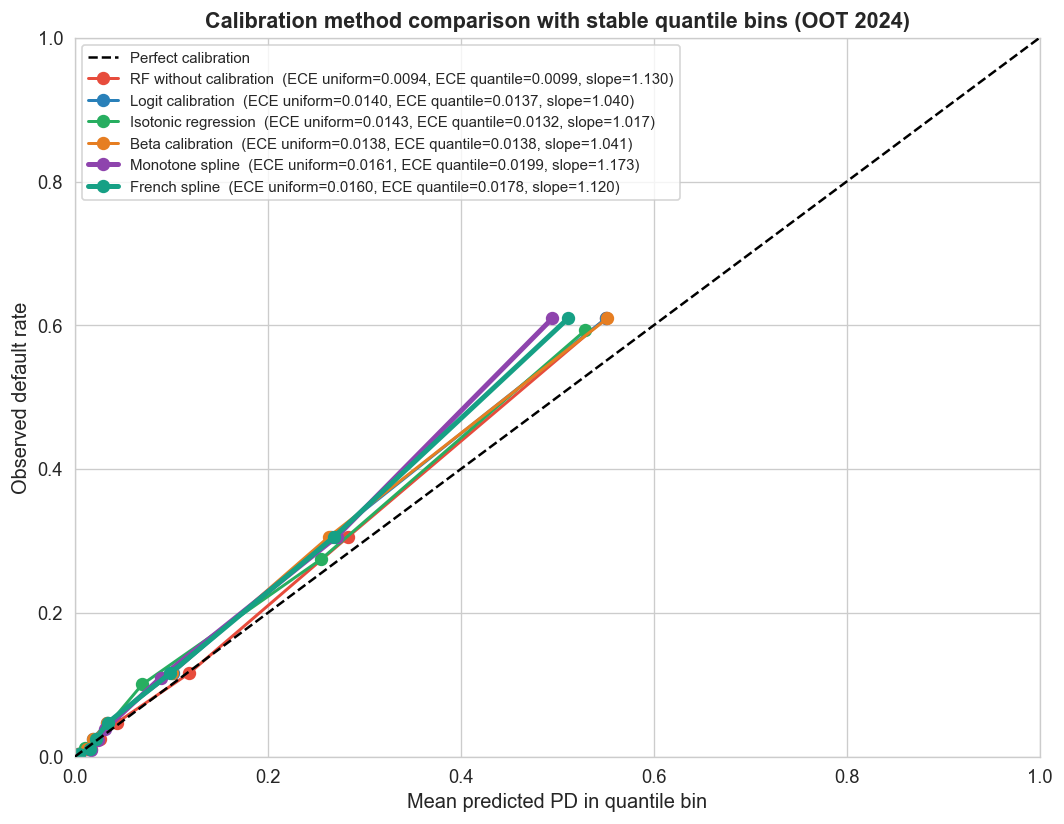

In [31]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect calibration", zorder=5)

for (name, probs), color in zip(all_methods.items(), COLORS):
    curve_table = calibration_bin_table(
        y_test.values,
        probs,
        n_bins=10,
        strategy="quantile",
        min_count=MIN_RELIABILITY_BIN_N,
    )
    plot_table = curve_table.loc[~curve_table["is_sparse"]].copy()
    m = summary_metrics(y_test.values, probs)
    lw = 3.0 if "spline" in name.lower() else 1.8
    label = f"{name}  (ECE uniform={m['ece_uniform']:.4f}, ECE quantile={m['ece_quantile']:.4f}, slope={m['cal_slope']:.3f})"
    ax.plot(plot_table["avg_pd"], plot_table["default_rate"], "o-", color=color, lw=lw, ms=7, label=label)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted PD in quantile bin", fontsize=12)
ax.set_ylabel("Observed default rate", fontsize=12)
ax.set_title("Calibration method comparison with stable quantile bins (OOT 2024)", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


### Вогнутая функция совокупного капитала под кредитный риск

В данном блоке для каждого метода калибровки строится зависимость между вероятностью дефолта `PD` и отношением капитала к `EAD`. Совокупный капитал разбивается на две части:

- `K_EL = EL / EAD` — ожидаемые потери как доля от экспозиции;
- `K_UL = UL capital / EAD` — капитал под неожиданные потери как доля от экспозиции.

Суммарная кривая `K_EL + K_UL` показывает, как изменение PD влияет на резервирование и капитальную нагрузку. Отдельные графики строятся по каждому методу калибровки, а общий график позволяет сопоставить итоговую капитальную кривую между методами.

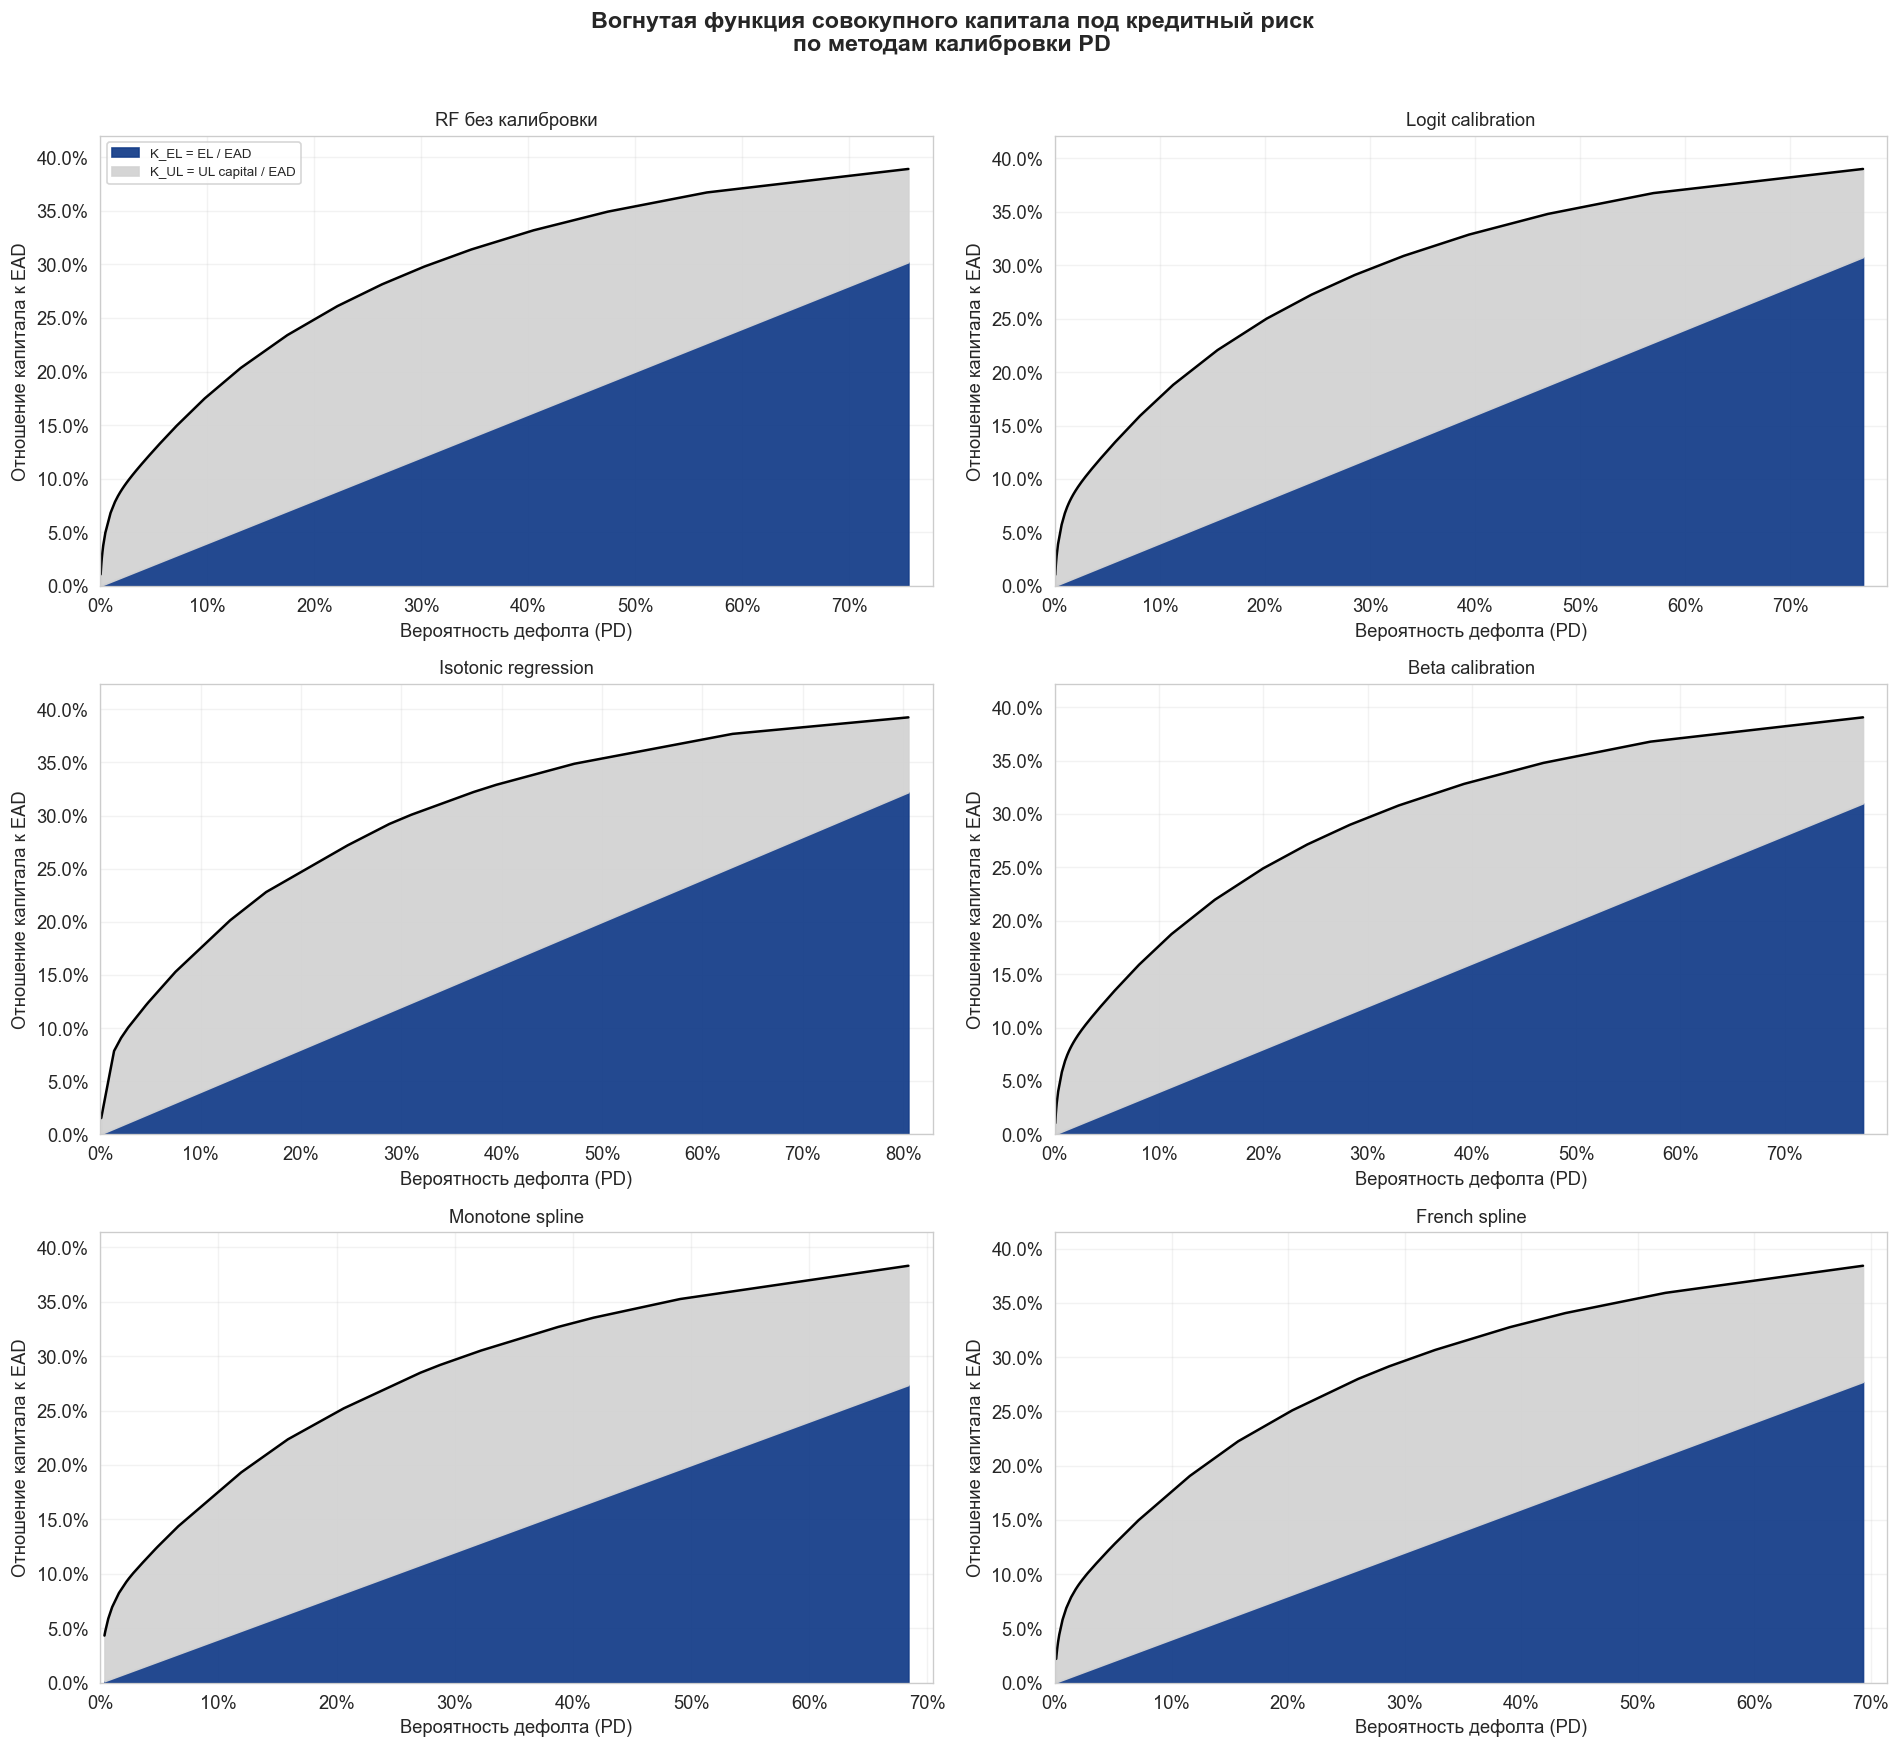

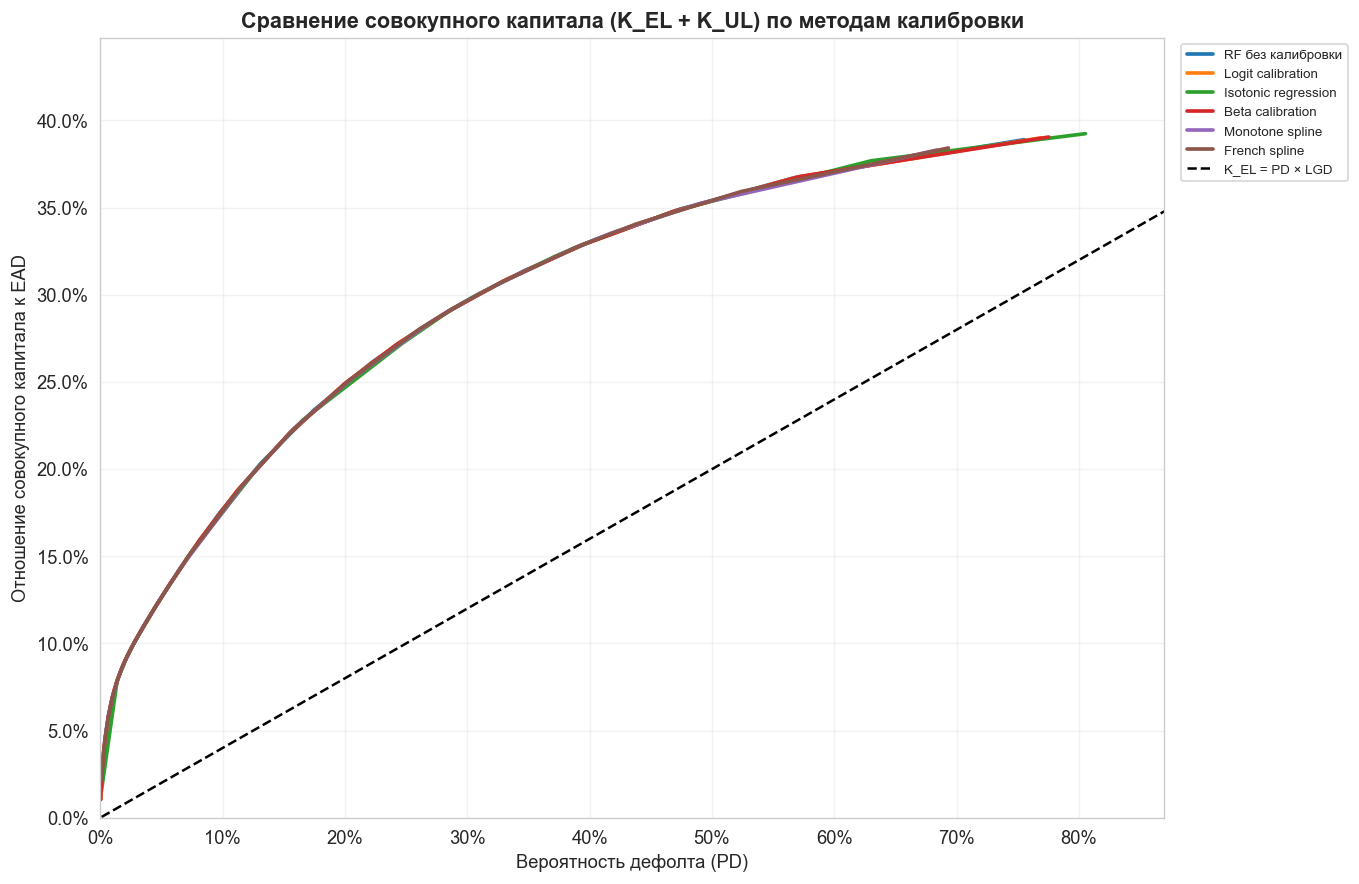

,avg_pd,avg_k_el_ratio,avg_k_ul_ratio,avg_k_total_ratio,max_pd
method,,,,,
RF без калибровки,10.46%,4.19%,8.20%,12.38%,93.83%
Logit calibration,9.86%,3.95%,7.64%,11.58%,95.01%
Isotonic regression,9.88%,3.95%,7.40%,11.35%,100.00%
Beta calibration,9.86%,3.95%,7.66%,11.61%,95.56%
Monotone spline,9.58%,3.83%,8.93%,12.76%,71.16%
French spline,9.59%,3.84%,8.29%,12.12%,71.51%


In [32]:
# =========================
# Вогнутая функция совокупного капитала под кредитный риск
# Для каждого метода калибровки + общий график
# =========================

capital_curve_methods = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

def build_capital_curve(pd_values, assumptions, n_bins=40):
    """
    Строит сглаженную эмпирическую кривую:
    PD -> K_EL/EAD, K_UL/EAD, K_total/EAD
    
    n_bins: число квантильных бинов для сглаживания.
    """
    pd_values = np.clip(np.asarray(pd_values, dtype=float), 1e-6, 1 - 1e-6)
    pd_values = np.sort(pd_values)

    tmp = calculate_irb_capital(pd_values, assumptions=assumptions).copy()
    tmp["k_el_ratio"] = tmp["expected_loss"] / tmp["ead"]
    tmp["k_ul_ratio"] = tmp["unexpected_loss_capital"] / tmp["ead"]
    tmp["k_total_ratio"] = tmp["k_el_ratio"] + tmp["k_ul_ratio"]

    # Сглаживание через квантильные бины
    if n_bins is not None and len(tmp) > n_bins:
        tmp["pd_bin"] = pd.qcut(tmp["pd"], q=n_bins, duplicates="drop")
        curve = (
            tmp.groupby("pd_bin", observed=True)
            .agg(
                pd=("pd", "mean"),
                k_el_ratio=("k_el_ratio", "mean"),
                k_ul_ratio=("k_ul_ratio", "mean"),
                k_total_ratio=("k_total_ratio", "mean"),
                n=("pd", "size"),
            )
            .reset_index(drop=True)
            .sort_values("pd")
        )
    else:
        curve = tmp[["pd", "k_el_ratio", "k_ul_ratio", "k_total_ratio"]].copy()

    return curve


# -------------------------
# 1. Индивидуальные графики для каждого метода
# -------------------------
n_methods = len(capital_curve_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (method, probs) in enumerate(capital_curve_methods.items()):
    ax = axes[i]
    curve = build_capital_curve(probs, capital_assumptions, n_bins=40)

    # Нижняя часть: K_EL
    ax.fill_between(
        curve["pd"],
        0,
        curve["k_el_ratio"],
        color="#173f8a",
        alpha=0.95,
        label="K_EL = EL / EAD",
    )

    # Верхняя часть: K_UL
    ax.fill_between(
        curve["pd"],
        curve["k_el_ratio"],
        curve["k_total_ratio"],
        color="lightgray",
        alpha=0.95,
        label="K_UL = UL capital / EAD",
    )

    # Граница суммарного капитала
    ax.plot(
        curve["pd"],
        curve["k_total_ratio"],
        color="black",
        linewidth=1.5,
    )

    ax.set_title(method, fontsize=11)
    ax.set_xlabel("Вероятность дефолта (PD)")
    ax.set_ylabel("Отношение капитала к EAD")
    ax.set_xlim(0, min(1.0, curve["pd"].max() * 1.03))
    ax.set_ylim(0, max(0.35, curve["k_total_ratio"].max() * 1.08))
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(True, alpha=0.25)

    if i == 0:
        ax.legend(fontsize=8, loc="upper left")

# убрать пустые оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Вогнутая функция совокупного капитала под кредитный риск\n"
    "по методам калибровки PD",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()


# -------------------------
# 2. Общий график: сравнение суммарной кривой капитала
# -------------------------
capital_curves = {
    method: build_capital_curve(probs, capital_assumptions, n_bins=40)
    for method, probs in capital_curve_methods.items()
}

max_curve_pd = max(float(curve["pd"].max()) for curve in capital_curves.values())
max_curve_capital = max(float(curve["k_total_ratio"].max()) for curve in capital_curves.values())

pd_grid = np.linspace(0.001, max(0.999, max_curve_pd), 300)
k_el_grid = pd_grid * capital_assumptions.lgd
max_reference_capital = float(k_el_grid.max())

fig, ax = plt.subplots(figsize=(14, 7.5))

for method, curve in capital_curves.items():
    ax.plot(
        curve["pd"],
        curve["k_total_ratio"],
        linewidth=2.2,
        label=method,
    )

# Для ориентира: ожидаемые потери без UL capital. 
ax.plot(
    pd_grid,
    k_el_grid,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="K_EL = PD × LGD",
)

ax.set_title(
    "Сравнение совокупного капитала (K_EL + K_UL) по методам калибровки",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Вероятность дефолта (PD)")
ax.set_ylabel("Отношение совокупного капитала к EAD")
ax.set_xlim(0, min(1.0, max_curve_pd * 1.08))
ax.set_ylim(0, max(max_curve_capital, max_reference_capital) * 1.12)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


# -------------------------
# 3. Таблица-резюме по среднему уровню капитала
# -------------------------
capital_curve_summary = []

for method, probs in capital_curve_methods.items():
    tmp = calculate_irb_capital(probs, assumptions=capital_assumptions).copy()

    capital_curve_summary.append({
        "method": method,
        "avg_pd": np.mean(tmp["pd"]),
        "avg_k_el_ratio": np.mean(tmp["expected_loss"] / tmp["ead"]),
        "avg_k_ul_ratio": np.mean(tmp["unexpected_loss_capital"] / tmp["ead"]),
        "avg_k_total_ratio": np.mean(
            (tmp["expected_loss"] + tmp["unexpected_loss_capital"]) / tmp["ead"]
        ),
        "max_pd": np.max(tmp["pd"]),
    })

capital_curve_summary = pd.DataFrame(capital_curve_summary).set_index("method")

display(
    capital_curve_summary.style.format({
        "avg_pd": "{:.2%}",
        "avg_k_el_ratio": "{:.2%}",
        "avg_k_ul_ratio": "{:.2%}",
        "avg_k_total_ratio": "{:.2%}",
        "max_pd": "{:.2%}",
    })
)

## 8. Выводы, практическая интерпретация и ограничения

In [33]:
print("=" * 90)
print("ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ КАЛИБРОВКИ PD")
print("=" * 90)

# =========================
# 1. Компактная таблица статистических метрик
# =========================

metric_cols = [
    "brier_score",
    "log_loss",
    "ece_uniform",
    "ece_quantile",
    "hl_p_value",
    "cal_slope",
    "cal_intercept",
]

df_metrics_final = (
    df_results[metric_cols]
    .sort_values(["brier_score", "log_loss", "ece_quantile"])
    .copy()
)

display(
    df_metrics_final.style.format({
        "brier_score": "{:.5f}",
        "log_loss": "{:.5f}",
        "ece_uniform": "{:.5f}",
        "ece_quantile": "{:.5f}",
        "hl_p_value": "{:.3f}",
        "cal_slope": "{:.3f}",
        "cal_intercept": "{:.3f}",
    })
)


# =========================
# 2. Компактная таблица backtesting expected defaults
# =========================

if "method_summary" in globals():
    df_backtest_final = method_summary[[
        "avg_pd",
        "defaults",
        "expected_defaults",
        "default_gap",
        "calibration_ratio",
    ]].copy()

    df_backtest_final["abs_default_gap"] = df_backtest_final["default_gap"].abs()

    display(
        df_backtest_final
        .sort_values("abs_default_gap")
        .style.format({
            "avg_pd": "{:.2%}",
            "defaults": "{:.0f}",
            "expected_defaults": "{:.2f}",
            "default_gap": "{:.2f}",
            "calibration_ratio": "{:.2f}",
            "abs_default_gap": "{:.2f}",
        })
    )


# =========================
# 3. Компактная таблица capital impact
# =========================

h1_col = (
    "h1_0_if_keep_rf_capital"
    if "h1_0_if_keep_rf_capital" in df_rwa.columns
    else "h1_if_keep_raw_capital"
)

df_capital_final = df_rwa[[
    "avg_pd",
    "total_expected_loss",
    "total_regulatory_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    h1_col,
]].copy()

df_capital_final["total_expected_loss"] = df_capital_final["total_expected_loss"] / 1_000_000_000
df_capital_final["total_regulatory_rwa"] = df_capital_final["total_regulatory_rwa"] / 1_000_000_000
df_capital_final["total_required_capital"] = df_capital_final["total_required_capital"] / 1_000_000_000

df_capital_final = df_capital_final.rename(columns={
    "avg_pd": "Средняя PD",
    "total_expected_loss": "EL / Reserves, млрд",
    "total_regulatory_rwa": "RWA, млрд",
    "total_required_capital": "Требуемый капитал, млрд",
    "rwa_saving_vs_baseline_pct": "Снижение RWA vs RF",
    h1_col: "Н1.0 при капитале RF",
})

display(
    df_capital_final
    .sort_values("RWA, млрд")
    .style.format({
        "Средняя PD": "{:.2%}",
        "EL / Reserves, млрд": "{:.3f}",
        "RWA, млрд": "{:.3f}",
        "Требуемый капитал, млрд": "{:.3f}",
        "Снижение RWA vs RF": "{:.2%}",
        "Н1.0 при капитале RF": "{:.2%}",
    })
)


# =========================
# 4. Автоматическое определение лучших методов по критериям
# =========================

best_brier = df_results["brier_score"].idxmin()
best_logloss = df_results["log_loss"].idxmin()
best_ece = df_results["ece_quantile"].idxmin()
best_rwa = df_rwa["total_rwa"].idxmin()
best_capital = df_rwa["total_required_capital"].idxmin()

if "method_summary" in globals():
    best_backtest = method_summary["default_gap"].abs().idxmin()
else:
    best_backtest = "не рассчитано"

summary_table = pd.DataFrame([
    {
        "Критерий": "Минимальный Brier Score",
        "Лучший метод": best_brier,
        "Значение": f"{df_results.loc[best_brier, 'brier_score']:.5f}",
        "Интерпретация": "Лучшее среднее качество вероятностного прогноза.",
    },
    {
        "Критерий": "Минимальный Log-Loss",
        "Лучший метод": best_logloss,
        "Значение": f"{df_results.loc[best_logloss, 'log_loss']:.5f}",
        "Интерпретация": "Наиболее сильный результат с учетом штрафа за уверенные ошибки.",
    },
    {
        "Критерий": "Минимальный ECE на квантильных бинах",
        "Лучший метод": best_ece,
        "Значение": f"{df_results.loc[best_ece, 'ece_quantile']:.5f}",
        "Интерпретация": "Лучшее совпадение прогнозных PD с фактическими дефолтами по группам риска.",
    },
    {
        "Критерий": "Минимальная ошибка expected defaults",
        "Лучший метод": best_backtest,
        "Значение": (
            f"{method_summary.loc[best_backtest, 'default_gap']:.2f}"
            if "method_summary" in globals()
            else "—"
        ),
        "Интерпретация": "Лучшее совпадение с фактическим числом дефолтов на OOT.",
    },
    {
        "Критерий": "Минимальный RWA",
        "Лучший метод": best_rwa,
        "Значение": f"{df_rwa.loc[best_rwa, 'total_rwa'] / 1_000_000_000:.3f} млрд",
        "Интерпретация": "Наименьшая капитальная нагрузка по IRB-style расчету.",
    },
    {
        "Критерий": "Минимальный требуемый капитал",
        "Лучший метод": best_capital,
        "Значение": f"{df_rwa.loc[best_capital, 'total_required_capital'] / 1_000_000_000:.3f} млрд",
        "Интерпретация": "Минимальный капитал при нормативе Н1.0 = 8%.",
    },
])

display(summary_table)


# =========================
# 5. Итоговый текстовый вывод
# =========================

print("\n" + "=" * 90)
print("ИТОГОВЫЙ ВЫВОД")
print("=" * 90)

print(
    "1. Единого лучшего метода калибровки нет: разные методы выигрывают по разным критериям. "
    "Поэтому выбор метода нельзя делать только по одной метрике."
)

print(
    f"2. По статистическим метрикам лучшие результаты дают: "
    f"Brier Score — {best_brier}, Log-Loss — {best_logloss}, ECE — {best_ece}."
)

if "method_summary" in globals():
    print(
        f"3. По агрегированному backtesting expected defaults лучший результат показывает: {best_backtest}. "
        "Это важно, потому что метод с хорошими Brier / Log-Loss не обязательно лучше попадает "
        "в фактическое число дефолтов портфеля."
    )

print(
    f"4. Минимальный RWA дает: {best_rwa}; минимальный требуемый капитал дает: {best_capital}. "
    "Однако снижение капитала нельзя трактовать как автоматическое улучшение модели, "
    "если одновременно ухудшается совпадение с фактическими дефолтами."
)

print(
    "5. Метрики ранжирования AUC / Gini / KS почти не меняются после калибровки, "
    "поскольку калибраторы в основном сохраняют порядок заемщиков и меняют именно уровень PD."
)

print(
    f"6. Rating Master Scale A1...E является отдельным уровнем анализа: все методы приводятся "
    f"к целевой CT calibration-периода ({TARGET_CT:.2%}), поэтому в этом блоке сравнивается "
    "не общий уровень expected defaults, а форма рейтинговой PD-кривой."
)

print(
    "7. Для итоговой интерпретации наиболее корректно сопоставлять сразу три блока: "
    "статистические метрики PD, backtesting expected defaults и влияние на RWA / Н1.0."
)

ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ КАЛИБРОВКИ PD


,brier_score,log_loss,ece_uniform,ece_quantile,hl_p_value,cal_slope,cal_intercept
method,,,,,,,
RF без калибровки,0.06097,0.19647,0.00936,0.00988,0.079,1.130,0.256
Beta calibration,0.06107,0.19671,0.01381,0.01380,0.005,1.041,0.271
Logit calibration,0.06108,0.19676,0.01400,0.01371,0.005,1.040,0.268
Isotonic regression,0.06139,0.19716,0.01427,0.01316,0.000,1.017,0.241
French spline,0.06195,0.19948,0.01597,0.01783,0.000,1.120,0.400
Monotone spline,0.06228,0.20101,0.01614,0.01990,0.000,1.173,0.469


,avg_pd,defaults,expected_defaults,default_gap,calibration_ratio,abs_default_gap
method,,,,,,
RF без калибровки,10.46%,713,666.77,46.23,1.07,46.23
Isotonic regression,9.87%,713,629.13,83.87,1.13,83.87
Logit calibration,9.86%,713,628.48,84.52,1.13,84.52
Beta calibration,9.86%,713,628.47,84.53,1.13,84.53
French spline,9.59%,713,611.23,101.77,1.17,101.77
Monotone spline,9.58%,713,610.16,102.84,1.17,102.84


,Средняя PD,"EL / Reserves, млрд","RWA, млрд","Требуемый капитал, млрд",Снижение RWA vs RF,Н1.0 при капитале RF
method,,,,,,
Isotonic regression,9.88%,0.252,5.893,0.792,9.73%,8.86%
Logit calibration,9.86%,0.251,6.083,0.807,6.82%,8.59%
Beta calibration,9.86%,0.251,6.105,0.809,6.49%,8.56%
RF без калибровки,10.46%,0.267,6.528,0.855,0.00%,8.00%
French spline,9.59%,0.244,6.601,0.843,-1.11%,7.91%
Monotone spline,9.58%,0.244,7.110,0.885,-8.91%,7.35%


,Критерий,Лучший метод,Значение,Интерпретация
0,Минимальный Brier Score,RF без калибровки,0.06097,Лучшее среднее качество вероятностного прогноза.
1,Минимальный Log-Loss,RF без калибровки,0.19647,Наиболее сильный результат с учетом штрафа за ...
2,Минимальный ECE на квантильных бинах,RF без калибровки,0.00988,Лучшее совпадение прогнозных PD с фактическими...
3,Минимальная ошибка expected defaults,RF без калибровки,46.23,Лучшее совпадение с фактическим числом дефолто...
4,Минимальный RWA,Isotonic regression,0.471 млрд,Наименьшая капитальная нагрузка по IRB-style р...
5,Минимальный требуемый капитал,Isotonic regression,0.792 млрд,Минимальный капитал при нормативе Н1.0 = 8%.



ИТОГОВЫЙ ВЫВОД
1. Единого лучшего метода калибровки нет: разные методы выигрывают по разным критериям. Поэтому выбор метода нельзя делать только по одной метрике.
2. По статистическим метрикам лучшие результаты дают: Brier Score — RF без калибровки, Log-Loss — RF без калибровки, ECE — RF без калибровки.
3. По агрегированному backtesting expected defaults лучший результат показывает: RF без калибровки. Это важно, потому что метод с хорошими Brier / Log-Loss не обязательно лучше попадает в фактическое число дефолтов портфеля.
4. Минимальный RWA дает: Isotonic regression; минимальный требуемый капитал дает: Isotonic regression. Однако снижение капитала нельзя трактовать как автоматическое улучшение модели, если одновременно ухудшается совпадение с фактическими дефолтами.
5. Метрики ранжирования AUC / Gini / KS почти не меняются после калибровки, поскольку калибраторы в основном сохраняют порядок заемщиков и меняют именно уровень PD.
6. Rating Master Scale A1...E является отдельным уровне

## Проверка устойчивости: миграция по мастер-шкале и чувствительность капитала

Этот блок фиксирует портфель 2024 года и показывает, как разные калибровки распределяют одни и те же наблюдения по заданной PD-мастер-шкале. Дополнительно рассчитываются чувствительность капитала по нижней, средней и верхней PD внутри рейтинга, сценарии delta-logit и волатильность капитала между методами калибровки.